# 06_11 - cell-type restriction of the entropy change, UNCONDITIONAL denominator, depth-matched

In [ ]:
print("Hello World")

In [1]:
# relocation-proof bootstrap
import os
import sys

_d = os.path.abspath(os.getcwd())
while not os.path.exists(os.path.join(_d, '.notebooks_root')):
    _p = os.path.dirname(_d)
    if _p == _d:
        raise RuntimeError('could not locate .notebooks_root above this notebook')
    _d = _p
os.chdir(_d)
if _d not in sys.path:
    sys.path.insert(0, _d)
print('working dir:', os.getcwd())

import gc
import warnings
import numpy as np
import pandas as pd
from scipy import stats
from scipy.sparse import issparse, csr_matrix
import matplotlib
import matplotlib.pyplot as plt

import importlib
import figure_paths
importlib.reload(figure_paths)
from figure_paths import figpath
import senescence_robustness as sr
importlib.reload(sr)

warnings.filterwarnings('ignore', category=RuntimeWarning)
pd.set_option('display.width', 240)

working dir: /oak/stanford/groups/quake/mmantri/group.quake/tabula_longread/notebooks


In [56]:
# preferred plot formatting
TICK_LEN = 2.0
TICK_LABEL_PAD = 1.5
AXIS_LABEL_PAD = 1.5
PANEL_TITLE_PAD = 3.0
plt.rcParams.update({
    'font.size': 6, 'axes.titlesize': 6, 'axes.labelsize': 6,
    'xtick.labelsize': 6, 'ytick.labelsize': 6,
    'legend.fontsize': 6, 'legend.title_fontsize': 6,
    'legend.labelspacing': 0.1, 'legend.borderpad': 0.3, 'legend.handletextpad': 0.2,
    'figure.titlesize': 6,
    'axes.labelweight': 'bold', 'axes.titleweight': 'bold', 'figure.titleweight': 'bold',
    'xtick.major.size': TICK_LEN, 'ytick.major.size': TICK_LEN,
    'xtick.major.pad': TICK_LABEL_PAD, 'ytick.major.pad': TICK_LABEL_PAD,
    'axes.labelpad': AXIS_LABEL_PAD,
})
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['Arial'] + matplotlib.rcParams['font.sans-serif']
matplotlib.rcParams['mathtext.fontset'] = 'custom'
matplotlib.rcParams['mathtext.rm'] = 'Arial'
matplotlib.rcParams['mathtext.it'] = 'Arial:italic'
matplotlib.rcParams['mathtext.bf'] = 'Arial:bold'
matplotlib.rcParams['mathtext.cal'] = 'Arial:italic'
matplotlib.rcParams['mathtext.sf'] = 'Arial'
matplotlib.rcParams['mathtext.tt'] = 'Arial'

UP_COLOR = '#c44e52'
DOWN_COLOR = '#4c72b0'
UNDERPOWERED_COLOR = '#d9d9d9'

H5AD_DIR = '../pacbio/h5ads'
CSV_DIR = '../csvs'
OUT = CSV_DIR + '/06_36_robustness'
os.makedirs(OUT, exist_ok=True)
OBJ = (H5AD_DIR + '/all_samples_pacbio_recollapsed_raw_counts_ensemblids_annotatedonly'
       '_bc_anndata_preprocessed_with_isofrac_xgen_cdkn2a.h5ad')
STATUS_COL = 'xgen_cdkn2a_raw_status'
# --- ESTIMAND -------------------------------------------------------------
# 1 -> unconditional: denominator is cells EXPRESSING the gene (nexp >= 1)
# 2 -> conditional:   cells already using >= 2 isoforms, i.e. 06_11
# Only the divisor changes; ss / sq are identical either way (see header).
MIN_ISOFORMS_FOR_DENOMINATOR = 1

# --- DEPTH CONTROL --------------------------------------------------------
# 1:1 depth matching applied BEFORE any accumulation, so every quantity in this
# notebook is depth-controlled and there is no uncorrected arm to confuse it with.
MATCH_BINS = 20
MATCH_SEED = 1
# MATCH_WITHIN nests the 1:1 depth match inside a grouping.
#   None or []          -> pooled over all cells
#   ['tube_id']         -> matched WITHIN SAMPLE (current)
#   ['tube_id', 'broad_cell_class'] -> also within cell class
MATCH_WITHIN = ['broad_cell_class']
MIN_SEN_PER_CLASS = 50     # classes below this are reported untested, not dropped
# Matches 06_10, which applies the SAME gate to the same quantity on POOLED cells.
# Splitting a gene across 10 classes leaves far fewer cells per arm, so a stricter
# value sits on the thinner data and inflates the underpowered share this notebook
# reports. 06_08 handles the same asymmetry the other way (MIN_PER_STRATUM 5 ->
# MIN_PER_STRATUM_CT 3 per class).
MIN_CELLS_PER_ARM = 5      # per (gene, class) arm, for that pair to be estimable
# Moved here from sections 7 and 9b, where they were defined mid-run (twice).
MIN_CELLS_PER_ARM_DONOR = 10   # per (gene, class, donor) arm; matches 06_10
MIN_CELLS_PER_GROUP = 5        # per donor, cells with >= 2 isoforms, for the boxes
MIN_EXPR_CELLS_PER_GROUP = 10  # per donor, cells EXPRESSING the gene; matches 06_10
# The >=2-isoform ARM FILTER is off; the gate is the EXPRESSING count only.
# MIN_CELLS_PER_GROUP is retained for the other two options.
DONOR_GATE = 'match_volcano'            # 'both' | 'match_volcano' | 'entropy_defined'
N_PERM = 1000
POWER_Z = 2.802            # z(0.975) + z(0.80): 80% power at alpha = 0.05
CHUNK = 4000
# --- HEATMAP DIRECTION FILTER ---------------------------------------------
# Which significant (gene, class) calls a gene may be selected on for the two
# heatmaps below. The direction is judged PER CELL CLASS, on that class's own
# effect, so 'up' means "this gene's entropy INCREASES in this class".
#   'both' -> every significant call            (default; 06_47c behaviour)
#   'up'   -> increases only  (eff > 0)
#   'down' -> decreases only  (eff < 0)
# Filtered figures get an _up / _down filename suffix so they cannot overwrite
# the unfiltered panel, which is the one the manuscript currently points at.
HEATMAP_DIRECTION = 'up'
final = {}

## 1. Accumulate by (cell class, arm, gene)


In [57]:
import scanpy as sc
adata = sc.read_h5ad(OBJ)
st = adata.obs[STATUS_COL].astype(str)
adata = adata[(~st.isin(['other_CDKN2A+', 'p14ARF+'])).values].copy()
st = adata.obs[STATUS_COL].astype(str)
sen = st.isin(['p16+', 'Both']).values
gene_col = ('pigeon_associated_gene' if 'pigeon_associated_gene' in adata.var.columns
            else 'gene_name')
adata = adata[:, adata.var[gene_col].notna().values].copy()
iso_to_gene, gene_of_iso, genes, _ = sr.build_iso_to_gene(adata.var[gene_col].values)
n_genes = len(genes)

# ---------------------------------------------------------------- DEPTH MATCHING
# adata.X is raw counts on the isoform set already filtered to named genes, so this is the
# isoform-level library size -- the same quantity 06_10 / 06_56 / 06_57 match on. Matching
# keeps EVERY senescent cell and draws an equal number of reference cells from the same depth
# bin: it changes which cells are compared, never what is inside them, so no count is altered
# and no sampling noise is added.
depth_full = np.asarray(adata.X.sum(axis=1)).ravel()
_cls_pre = adata.obs['broad_cell_class'].astype(str).values
_cols_m = ([MATCH_WITHIN] if isinstance(MATCH_WITHIN, str)
           else list(MATCH_WITHIN or []))
_missing_m = [c for c in _cols_m if c not in adata.obs.columns]
assert not _missing_m, f'MATCH_WITHIN columns not in obs: {_missing_m}'
if _cols_m:
    # Zip raw values, never pd.Series(...).str.cat(adata.obs[...]): a bare numpy array
    # gets a RangeIndex while adata.obs is indexed by barcode, str.cat aligns on INDEX,
    # and the join silently produces all-NaN.
    _parts = [adata.obs[c].astype(str).values for c in _cols_m]
    _grp_pre = np.array(['||'.join(t) for t in zip(*_parts)])
    assert not pd.isna(_grp_pre).any(), 'composite grouping key has NaN'
    _grp_label = ' x '.join(_cols_m)
    _keep = []
    print(f'matching nested on {_grp_label}  '
          f'({len(pd.unique(_grp_pre)):,} groups)')
    for _c in np.unique(_grp_pre):
        _rows = np.where(_grp_pre == _c)[0]
        if sen[_rows].sum() == 0 or (~sen[_rows]).sum() == 0:
            continue                      # nothing to match against inside this group
        _mi, _mj = sr.depth_matched_indices(depth_full[_rows], sen[_rows],
                                            n_bins=MATCH_BINS, seed=MATCH_SEED, ratio=1)
        _keep.append(_rows[np.concatenate([_mi, _mj])])
    if not _keep:
        raise ValueError(
            f'no {_grp_label} group held both arms -- nothing to match. With this '
            f'nesting and MATCH_BINS={MATCH_BINS} the blocks may simply be too thin; '
            'lower MATCH_BINS, or drop a column from MATCH_WITHIN.')
    idx_m = np.sort(np.concatenate(_keep))
else:
    _grp_pre, _grp_label = None, 'global (pooled over all cells)'
    print('matching POOLED over all cells -- no nesting')
    _mi, _mj = sr.depth_matched_indices(depth_full, sen,
                                        n_bins=MATCH_BINS, seed=MATCH_SEED, ratio=1)
    idx_m = np.sort(np.concatenate([_mi, _mj]))


_n_before, _sen_before, _depth_before = adata.n_obs, sen.copy(), depth_full.copy()
adata = adata[idx_m].copy()               # subsets X, obs and layers together, so every
sen = sen[idx_m]                          # array derived below is on the matched cells
depth = depth_full[idx_m]
# The label is derived from BOTH switches. It used to read off MATCH_WITHIN_CLASS
# alone, so a class x tube run still printed 'WITHIN CLASS' and the CSV recorded
# 'within class' -- misdescribing how the matched arm was built.
_match_scheme = _grp_label.replace('_', ' ').upper()
print(f'\ndepth matching: {_match_scheme}, '
      f'{MATCH_BINS} bins, seed {MATCH_SEED}')
print(f'  matched subsample {adata.n_obs:,} of {_n_before:,} cells '
      f'({100 * adata.n_obs / _n_before:.1f}%), '
      f'{int(sen.sum()):,} senescent + {int((~sen).sum()):,} reference')
_dropped = int(_sen_before.sum()) - int(sen.sum())
if _dropped:
    print(f'  NOTE: {_dropped:,} senescent cells dropped -- their depth bin held no reference')
    print('  cell at all, so no pair could be formed.')
print(f"  Cliff's delta on depth, ALL CELLS  "
      f"BEFORE {sr.cliffs_delta(_depth_before[_sen_before], _depth_before[~_sen_before]):+.3f}"
      f"   AFTER {sr.cliffs_delta(depth[sen], depth[~sen]):+.3f}")

# PER-CLASS residual gap. Quote nothing from a class whose delta is still large: its
# detection term is not depth-controlled even though the marginal balance looks fine.
_cls_post = adata.obs['broad_cell_class'].astype(str).values
_rows_bal = []
for _c in np.unique(_cls_post):
    _m, _mb = _cls_post == _c, _cls_pre == _c
    if not ((_m & sen).any() and (_m & ~sen).any()):
        continue
    _rows_bal.append({
        'class': _c,
        'n_sen': int((_m & sen).sum()), 'n_ref': int((_m & ~sen).sum()),
        'med_depth_sen': float(np.median(depth[_m & sen])),
        'med_depth_ref': float(np.median(depth[_m & ~sen])),
        'cliffs_before': float(sr.cliffs_delta(_depth_before[_mb & _sen_before],
                                               _depth_before[_mb & ~_sen_before])),
        'cliffs_after': float(sr.cliffs_delta(depth[_m & sen], depth[_m & ~sen]))})
depth_balance = pd.DataFrame(_rows_bal).set_index('class')
print('\nper-class depth balance after matching:')
print(depth_balance.round(3).to_string())
_worst = depth_balance['cliffs_after'].abs().max()
print(f"\nlargest |Cliff's delta| remaining in any class: {_worst:.3f}")
if _worst > 0.1:
    print('  WARNING: at least one class still carries a non-trivial depth gap; its')
    print('  detection term is not depth-controlled. Treat that class as uncorrected.')
depth_balance.to_csv(OUT + '/06_11_depth_balance_by_class.csv')

cls_all = adata.obs['broad_cell_class'].astype(str).values
sen_per_class = pd.Series(cls_all[sen]).value_counts()
classes = sorted([c for c in sen_per_class.index if sen_per_class[c] >= MIN_SEN_PER_CLASS])
excluded = sorted([c for c in sen_per_class.index if sen_per_class[c] < MIN_SEN_PER_CLASS])
n_cls = len(classes)
cls_idx = {c: i for i, c in enumerate(classes)}
print(f'senescent cells per broad class: min {sen_per_class.min()}, '
      f'max {sen_per_class.max()} ({sen_per_class.max() / max(sen_per_class.min(), 1):.0f}x range)')
print(f'classes analysed (>= {MIN_SEN_PER_CLASS} senescent cells): {n_cls}')
print(f'classes UNTESTED (too few senescent cells): {len(excluded)} -> {excluded}')
print(sen_per_class.loc[classes].to_string())

# Structural testability. A (gene, class) pair is estimable only if BOTH arms
# hold at least MIN_CELLS_PER_ARM cells, so a class whose ENTIRE senescent
# population is smaller than that cannot yield a single estimable pair -- for
# any gene. At MIN_SEN_PER_CLASS = 5 such classes are admitted; they must be
# reported as STRUCTURALLY UNTESTABLE, not as null and not as underpowered,
# because no rearrangement of the data inside this design could ever test them.
struct_untestable = [c for c in classes
                     if sen_per_class[c] < MIN_CELLS_PER_ARM]
if struct_untestable:
    print()
    print(f'STRUCTURALLY UNTESTABLE: {len(struct_untestable)} of {n_cls} classes '
          f'hold fewer than MIN_CELLS_PER_ARM={MIN_CELLS_PER_ARM} senescent')
    print('cells, so their senescent arm can never be filled:')
    for _c in struct_untestable:
        print(f'  {_c:<34} {int(sen_per_class[_c]):>5} senescent cells')

tube = adata.obs['tube_id'].astype(str).values

# Permutation labels: shuffled WITHIN SAMPLE. There is no library-size term in
# the block because there is none in the observed effect either. Block
# membership is resolved ONCE -- the previous version scanned the full block
# array per (permutation, block), which alone dominates the runtime once N_PERM
# reaches the thousands. Row N_PERM carries the TRUE labels and is used for the
# self-check after the accumulation loop.
rng = np.random.default_rng(0)
block_idx = [np.where(tube == k)[0] for k in np.unique(tube)]
perm_labels = np.zeros((N_PERM + 1, len(sen)), dtype=bool)
for r in range(N_PERM):
    lab = sen.copy()
    for idx in block_idx:
        lab[idx] = rng.permutation(sen[idx])
    perm_labels[r] = lab
perm_labels[N_PERM] = sen                 # self-check row, not a permutation
print(f'permutation blocks: {len(block_idx)} samples')

frac = adata.layers['isoform_fraction']
frac = frac.tocsr() if issparse(frac) else csr_matrix(frac)

# Donor axis added so cross-donor robustness can be assessed by LEAVE-ONE-DONOR-
# OUT. Estimating per (donor, class) directly is not viable here: the smallest
# class has 34 senescent cells in total, so a four-way split leaves nothing
# estimable. LODO instead drops one donor at a time and keeps ~75% of the cells,
# and it costs no extra pass -- each LODO total is the full accumulator minus
# that donor's slice.
donor_arr = adata.obs['donor'].astype(str).values
don_list = sorted(set(donor_arr))
n_don = len(don_list)
don_idx = np.array([don_list.index(d) for d in donor_arr])
shape_d = (n_don, n_cls, 2, n_genes)
# float64, not float32: the permutation path below is a GEMM and the observed
# path is a masked gather, and the self-check compares them. float32 column
# sums drift at ~1e-4 relative, which would make that check vacuous.
nn_d = np.zeros(shape_d)   # nexp >= 1: the UNCONDITIONAL denominator
nm_d = np.zeros(shape_d)   # nexp >= 2: 06_11's conditional denominator, for comparison
ss_d = np.zeros(shape_d)
sq_d = np.zeros(shape_d)
print(f'donors: {don_list}')
print(f'donor-resolved accumulator: {shape_d} -> {nn_d.nbytes / 1e6:.0f} MB each')
shape = (n_cls, 2, n_genes)

# Permutation accumulators carry the SENESCENT ARM ONLY: [perm, class, gene].
# Labels are permuted within sample, which never moves a cell between classes,
# so the per-(class, gene) totals are permutation-invariant and the reference
# arm is exactly total - senescent. `pq` is new: with a sum of squares the null
# runs through class_effect, the same estimator as the observed effect, removing
# the unweighted-mean mismatch documented in the null cell.
pshape = (N_PERM + 1, n_cls, n_genes)
pn = np.zeros(pshape)
ps = np.zeros(pshape)
pq = np.zeros(pshape)
_acc_mb = float(np.prod(shape)) * 8 / 1e6
print(f'\naccumulator: {shape} -> {_acc_mb:.0f} MB each, '
      f'permutations 3 x {pshape} -> {3 * pn.nbytes / 1e9:.2f} GB total')

ci_all = np.array([cls_idx.get(c, -1) for c in cls_all])
for start in range(0, adata.n_obs, CHUNK):
    end = min(start + CHUNK, adata.n_obs)
    b = frac[start:end]
    term = b.copy()
    term.data = -term.data * np.log2(np.maximum(term.data, 1e-300))
    H = np.asarray((term @ iso_to_gene).todense(), dtype=np.float64)
    nexp = np.asarray(((b > 0).astype(np.float32) @ iso_to_gene).todense())
    expr = nexp >= 1          # UNCONDITIONAL denominator: cells expressing the gene
    meas = nexp >= 2          # conditional denominator (06_11), carried for comparison
    ci = ci_all[start:end]; sn = sen[start:end]
    di = don_idx[start:end]
    pl_chunk = perm_labels[:, start:end]
    for c in range(n_cls):
        inc = ci == c
        if not inc.any():
            continue
        for dd in range(n_don):
            incd = inc & (di == dd)
            if not incd.any():
                continue
            for a in (0, 1):
                m = incd & (sn == bool(a))
                if not m.any():
                    continue
                nn_d[dd, c, a] += expr[m].sum(axis=0)
                nm_d[dd, c, a] += meas[m].sum(axis=0)
                # np.where on `expr` rather than `meas`: identical VALUES, since H is
                # exactly 0 wherever one isoform was seen. Written on `expr` so the code
                # states the estimand rather than relying on that coincidence.
                hh = np.where(expr[m], H[m], 0.0)
                ss_d[dd, c, a] += hh.sum(axis=0)
                sq_d[dd, c, a] += (hh ** 2).sum(axis=0)
        # Permutations for this class as three GEMMs, replacing one masked
        # gather per (permutation, arm): the senescent-arm sums for every
        # permutation at once are P @ X, with P = [perm, cells] the 0/1 label
        # matrix and X = [cells, gene].
        idx_c = np.where(inc)[0]
        P = pl_chunk[:, idx_c].astype(np.float64)
        M_s = expr[idx_c].astype(np.float64)
        Hh = np.where(expr[idx_c], H[idx_c], 0.0)
        pn[:, c] += P @ M_s
        ps[:, c] += P @ Hh
        np.square(Hh, out=Hh)
        pq[:, c] += P @ Hh
        del P, M_s, Hh
    del b, term, H, nexp, expr, meas
    gc.collect()
    print(f'  {end:,}/{adata.n_obs:,}', flush=True)
# collapse the donor axis for everything downstream; LODO uses the slices
nn = nn_d.sum(axis=0)
nm = nm_d.sum(axis=0)
ss = ss_d.sum(axis=0)
sq = sq_d.sum(axis=0)

# SELF-CHECK. Row N_PERM held the true labels, so it must reproduce the observed
# senescent arm, and total-minus-senescent must reproduce the reference arm.
# This is the guard against the axis slip that hit this notebook and 06_10:
# reading one accumulator axis as the arm axis gives a null that is tight and
# far from 50%, which reads as a finding rather than as a bug.
for _nm, _p, _o in (('n', pn, nn), ('sum', ps, ss), ('sq', pq, sq)):
    _scale = max(1.0, float(np.abs(_o).max()))
    _r1 = float(np.abs(_p[N_PERM] - _o[:, 1]).max()) / _scale
    _r0 = float(np.abs((_o.sum(axis=1) - _p[N_PERM]) - _o[:, 0]).max()) / _scale
    assert _r1 < 1e-9, f'GEMM path != observed senescent arm ({_nm}, rel {_r1:.2e})'
    assert _r0 < 1e-9, f'total - senescent != reference arm ({_nm}, rel {_r0:.2e})'
    print(f'  self-check {_nm}: senescent {_r1:.1e}, reference {_r0:.1e}')
pn = pn[:N_PERM]
ps = ps[:N_PERM]
pq = pq[:N_PERM]
print('accumulation done')

# H > 0 requires >= 2 detected isoforms, so ss must be exactly 0 wherever nm is 0. The
# decomposition in section 2b relies on this.
assert float(np.abs(ss[nm == 0]).max() if (nm == 0).any() else 0.0) == 0.0, \
    'ss is non-zero where no cell detected two isoforms -- H should be 0 there'
print(f'denominator in force: '
      f"{'UNCONDITIONAL (nexp >= 1)' if MIN_ISOFORMS_FOR_DENOMINATOR == 1 else 'conditional (nexp >= 2)'}")
# nm / nm_d are accumulated: D = nm / nn is the decomposition's detection factor.


matching nested on broad_cell_class  (33 groups)

depth matching: BROAD CELL CLASS, 20 bins, seed 1
  matched subsample 6,268 of 154,182 cells (4.1%), 3,134 senescent + 3,134 reference
  Cliff's delta on depth, ALL CELLS  BEFORE +0.449   AFTER +0.013

per-class depth balance after matching:
                              n_sen  n_ref  med_depth_sen  med_depth_ref  cliffs_before  cliffs_after
class                                                                                                
cardiac endothelial cell          1      1         1683.0         1660.0          0.370         1.000
ciliated epithelial cell         77     77         7096.0         7079.0          0.350        -0.006
contractile cell                 34     34         2812.5         2808.0          0.475         0.031
dendritic cell                    2      2         1970.0         1802.5         -0.519         0.500
duct epithelial cell              5      5         8815.0         8147.0          0.646         

## 2. Per-(gene, class) stratified effects


In [58]:
def class_effect(n_, s_, q_, min_cells=MIN_CELLS_PER_ARM):
    """Difference in mean per-cell entropy between arms; vectorised over genes.

    n_/s_/q_ have shape [arm, gene]; arm 0 = reference, 1 = senescent.

    This is exactly what the inverse-variance-across-strata estimator collapses
    to at a single stratum -- there the weight w = 1/(se2_0 + se2_1) appears in
    both numerator and denominator and cancels, leaving the plain difference and
    se = sqrt(1/w). Written out rather than carried as a length-1 axis, since
    this notebook does not stratify (see the header).
    """
    with np.errstate(invalid='ignore', divide='ignore'):
        mean = s_ / n_
        var = (q_ / n_ - mean ** 2) * n_ / np.maximum(n_ - 1, 1)
        se2 = var / n_
        denom = se2[0] + se2[1]
    ok = ((n_[0] >= min_cells) & (n_[1] >= min_cells)
          & np.isfinite(denom) & (denom > 0))
    with np.errstate(invalid='ignore', divide='ignore'):
        eff = mean[1] - mean[0]
        se = np.sqrt(denom)
    return np.where(ok, eff, np.nan), np.where(ok, se, np.nan), ok


eff = np.full((n_cls, n_genes), np.nan)
se = np.full((n_cls, n_genes), np.nan)
for c in range(n_cls):
    e_, s_, ok_ = class_effect(nn[c], ss[c], sq[c])
    eff[c] = np.where(ok_, e_, np.nan)
    se[c] = np.where(ok_, s_, np.nan)

z = eff / se
p = 2 * stats.norm.sf(np.abs(z))
padj = np.full_like(p, np.nan)
for c in range(n_cls):
    padj[c] = sr.bh(p[c])
sig = padj < 0.05
testable = np.isfinite(eff)
mde = POWER_Z * se                       # smallest effect this class could detect

print('per class:')
summ = pd.DataFrame({
    'broad_cell_class': classes,
    'n_sen': [int(sen_per_class[c]) for c in classes],
    'structurally_untestable': [c in set(struct_untestable) for c in classes],
    'genes_testable': testable.sum(axis=1),
    'genes_sig': np.nansum(sig, axis=1).astype(int),
    'pct_increased': [100 * np.nanmean(eff[c][testable[c]] > 0) for c in range(n_cls)],
    'median_MDE': np.nanmedian(mde, axis=1),
}).sort_values('n_sen', ascending=False)
print(summ.round(4).to_string(index=False))
summ.to_csv(OUT + '/06_11_per_class_summary.csv', index=False)
print()
print(f'median MDE ranges {summ.median_MDE.min():.4f} to {summ.median_MDE.max():.4f} '
      f'({summ.median_MDE.max() / summ.median_MDE.min():.0f}x) -- this spread IS the')
print('confound: a class with a large MDE cannot report a change it is not powered to see.')
final['n_classes'] = n_cls
final['mde_ratio'] = float(summ.median_MDE.max() / summ.median_MDE.min())

print(f'\ntestable (gene, class) pairs: {int(testable.sum()):,}')
final['n_testable_uncond'] = int(testable.sum())
final['depth_matching'] = _grp_label
final['depth_match_bins'] = int(MATCH_BINS)
final['n_match_groups'] = (int(len(pd.unique(_grp_pre)))
                           if _grp_pre is not None else 1)
final['n_cells_matched'] = int(adata.n_obs)

per class:
            broad_cell_class  n_sen  structurally_untestable  genes_testable  genes_sig  pct_increased  median_MDE
              male germ cell   1340                    False            9551       2153        43.8802      0.0926
     lymphocyte of b lineage    487                    False            7163         27        60.0726      0.1369
           myeloid leukocyte    278                    False            7144        294        65.3415      0.1744
                  fibroblast    186                    False            5181         11        60.2779      0.2085
transitional epithelial cell    166                    False            4478         20        47.2756      0.2001
                      t cell    148                    False            4052         25        67.0286      0.2397
                   stem cell    115                    False            3618          0        41.0724      0.3116
    ciliated epithelial cell     77                    False         

## 2b. Detection vs evenness, per (gene, class)


decomposition closes on 54,171 (gene, class) pairs, max |delta| 3.89e-16
detection term dominates in 78.4% of testable pairs

per-class share of significant pairs where DETECTION dominates:
                              n_sig  pct_detection_dominant  mean_term_detection  mean_term_evenness
class                                                                                               
male germ cell                 2153                 94.5193              -0.0242             -0.0076
myeloid leukocyte               294                 88.0952               0.1527              0.0421
lymphocyte of b lineage          27                 85.1852               0.0611             -0.0090
t cell                           25                100.0000               0.3341              0.0155
transitional epithelial cell     20                 70.0000              -0.1193             -0.0767
fibroblast                       11                 90.9091               0.3345              0.0656
ci

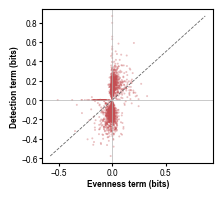

In [59]:
with np.errstate(invalid='ignore', divide='ignore'):
    D = nm / np.maximum(nn, 1e-300)                    # [class, arm, gene]
    M_ = np.where(nm > 0, ss / np.maximum(nm, 1), 0.0)
    mean_uncond = ss / np.maximum(nn, 1e-300)          # == D * M_

term_detection = M_[:, 1] * (D[:, 1] - D[:, 0])
term_evenness = D[:, 0] * (M_[:, 1] - M_[:, 0])

_chk = testable & np.isfinite(term_detection) & np.isfinite(term_evenness)
_lhs = (mean_uncond[:, 1] - mean_uncond[:, 0])[_chk]
_rhs = (term_detection + term_evenness)[_chk]
_maxdiff = float(np.abs(_lhs - _rhs).max()) if _chk.any() else 0.0
assert _maxdiff < 1e-9, f'decomposition does not close (max |delta| {_maxdiff:.2e})'
print(f'decomposition closes on {int(_chk.sum()):,} (gene, class) pairs, '
      f'max |delta| {_maxdiff:.2e}')

_dom_det = np.abs(term_detection) > np.abs(term_evenness)
print(f'detection term dominates in {100 * np.nanmean(_dom_det[_chk]):.1f}% of testable pairs')
final['pct_detection_dominant'] = float(100 * np.nanmean(_dom_det[_chk]))

_rows_d = []
for c in range(n_cls):
    m = _chk[c] & sig[c]
    _rows_d.append({'class': classes[c], 'n_sig': int(m.sum()),
                    'pct_detection_dominant': float(100 * np.nanmean(_dom_det[c][m])) if m.any() else np.nan,
                    'mean_term_detection': float(np.nanmean(term_detection[c][m])) if m.any() else np.nan,
                    'mean_term_evenness': float(np.nanmean(term_evenness[c][m])) if m.any() else np.nan})
class_decomp = pd.DataFrame(_rows_d).set_index('class').sort_values('n_sig', ascending=False)
print('\nper-class share of significant pairs where DETECTION dominates:')
print(class_decomp.round(4).to_string())
class_decomp.to_csv(OUT + '/06_11_decomposition_by_class.csv')

fig, ax = plt.subplots(figsize=(2.2, 2.0))
_m = _chk & sig
ax.scatter(term_evenness[_m], term_detection[_m], s=2, alpha=0.35,
           color=UP_COLOR, edgecolors='none')
_lo = float(np.nanmin([term_evenness[_m].min(), term_detection[_m].min()])) if _m.any() else -1
_hi = float(np.nanmax([term_evenness[_m].max(), term_detection[_m].max()])) if _m.any() else 1
ax.plot([_lo, _hi], [_lo, _hi], ls='--', lw=0.6, color='0.4')
ax.axhline(0, lw=0.5, color='0.7'); ax.axvline(0, lw=0.5, color='0.7')
ax.set_xlabel('Evenness term (bits)')
ax.set_ylabel('Detection term (bits)')
ax.tick_params(length=TICK_LEN, pad=TICK_LABEL_PAD)
fig.savefig(figpath('06_11_decomposition_detection_vs_evenness.pdf'),
            bbox_inches='tight', dpi=300)
plt.show()

In [60]:
# Cross-donor robustness by leave-one-donor-out. A (gene, class) call is robust
# only if dropping ANY single donor leaves the sign unchanged -- the direct test
# of whether one donor (or one dominant sample within it) carries the result.
lodo_eff = np.full((n_don, n_cls, n_genes), np.nan)
for dd in range(n_don):
    for c in range(n_cls):
        e_, s_, ok_ = class_effect(nn[c] - nn_d[dd, c],
                                   ss[c] - ss_d[dd, c],
                                   sq[c] - sq_d[dd, c])
        lodo_eff[dd, c] = np.where(ok_, e_, np.nan)

same_sign = np.sign(lodo_eff) == np.sign(eff)[None, :, :]
n_ok_lodo = np.sum(np.isfinite(lodo_eff), axis=0)      # LODO subsets estimable
n_agree = np.nansum(same_sign, axis=0)                 # ...that match the full sign
n_flip = n_ok_lodo - n_agree                           # ...that reverse it
finite = np.isfinite(eff)

# THREE-WAY, not two. The previous flag required BOTH "no sign flip" AND
# "estimable in all 4 leave-one-out subsets", so a call that simply became
# unestimable when a quarter of the cells were removed was recorded exactly
# like one that reversed. Those mean opposite things: a reversal is evidence
# against the call, a lost estimate is no evidence either way. Nine of the
# thirteen classes scored 0% robust under the old flag, and for the small
# classes that is a power failure, not donor-specificity.
fragile = finite & (n_flip > 0)                        # a reversal was OBSERVED
robust = finite & (n_flip == 0) & (n_ok_lodo == n_don)  # full coverage, no reversal
unresolved = finite & (n_flip == 0) & (n_ok_lodo < n_don)   # coverage lost

rows = []
for c in range(n_cls):
    a_ = testable[c] & sig[c]
    r_ = int((a_ & robust[c]).sum())
    f_ = int((a_ & fragile[c]).sum())
    u_ = int((a_ & unresolved[c]).sum())
    rows.append({'broad_cell_class': classes[c],
                 'n_sen': int(sen_per_class[classes[c]]),
                 'structurally_untestable': classes[c] in set(struct_untestable),
                 'significant': int(a_.sum()),
                 'robust': r_, 'fragile': f_, 'unresolved': u_,
                 # denominator EXCLUDES unresolved: it is the share of calls
                 # that LODO could actually adjudicate
                 'n_decided': r_ + f_,
                 'pct_robust_of_decided': 100 * r_ / max(r_ + f_, 1),
                 'pct_unresolved': 100 * u_ / max(int(a_.sum()), 1)})
rob = pd.DataFrame(rows).sort_values('n_sen', ascending=False)
print(rob.round(1).to_string(index=False))
rob.to_csv(OUT + '/06_11_lodo_robustness.csv', index=False)

tot_sig = int((testable & sig).sum())
tot_rob = int((testable & sig & robust).sum())
tot_fra = int((testable & sig & fragile).sum())
tot_unr = int((testable & sig & unresolved).sum())
dec = tot_rob + tot_fra
print()
print(f'significant (gene, class) calls          : {tot_sig:,}')
print(f'  robust     (all 4 LODO agree)          : {tot_rob:,}')
print(f'  fragile    (a reversal was observed)   : {tot_fra:,}')
print(f'  unresolved (lost estimability in LODO) : {tot_unr:,} '
      f'({100 * tot_unr / max(tot_sig, 1):.1f}% of calls)')
print()
print(f'robustness among ADJUDICATED calls       : {tot_rob:,}/{dec:,} '
      f'({100 * tot_rob / max(dec, 1):.1f}%)')
print('The old headline divided by ALL significant calls, which counted every')
print('unresolved call as a failure and understated robustness in small classes')
print('while implying the small classes had been tested at all.')
print()
# Structurally untestable classes are separated FIRST. Leaving them in the
# "too few decided" bucket would blame leave-one-out for a limit that predates
# it: these classes could not be tested even with every donor present.
_su = rob[rob.structurally_untestable]
_rest = rob[~rob.structurally_untestable]
if len(_su):
    print('STRUCTURALLY UNTESTABLE -- fewer senescent cells than one arm')
    print('requires, so LODO says nothing about them and neither does the main')
    print('analysis:')
    for _, r in _su.iterrows():
        print(f"  {r['broad_cell_class']:<32} {int(r['n_sen']):>4} senescent cells, "
              f"{int(r['significant']):>4} significant")
    print()
_hi = _rest[_rest.n_decided >= 20]
_lo = _rest[_rest.n_decided < 20]
if len(_lo):
    print('Classes where LODO decided FEWER THAN 20 calls -- no donor claim, in')
    print('either direction, is supportable for these:')
    for _, r in _lo.iterrows():
        print(f"  {r['broad_cell_class']:<30} {int(r['significant']):>5} sig, "
              f"{int(r['n_decided']):>4} decided, "
              f"{int(r['unresolved']):>4} unresolved")
if len(_hi):
    print()
    print('Classes with an adjudicable donor verdict:')
    for _, r in _hi.iterrows():
        print(f"  {r['broad_cell_class']:<30} "
              f"{r['pct_robust_of_decided']:>5.1f}% robust "
              f"({int(r['robust'])}/{int(r['n_decided'])})")
final['n_sig_calls'] = tot_sig
final['n_sig_robust'] = tot_rob
final['n_sig_fragile'] = tot_fra
final['n_sig_unresolved'] = tot_unr
final['pct_sig_robust'] = float(100 * tot_rob / max(tot_sig, 1))
final['pct_robust_of_decided'] = float(100 * tot_rob / max(dec, 1))
final['n_classes_lodo_adjudicable'] = int(len(_hi))
final['n_classes_structurally_untestable'] = int(len(_su))

            broad_cell_class  n_sen  structurally_untestable  significant  robust  fragile  unresolved  n_decided  pct_robust_of_decided  pct_unresolved
              male germ cell   1340                    False         2153    1898      162          93       2060                   92.1             4.3
     lymphocyte of b lineage    487                    False           27      26        1           0         27                   96.3             0.0
           myeloid leukocyte    278                    False          294     231       49          14        280                   82.5             4.8
                  fibroblast    186                    False           11       8        2           1         10                   80.0             9.1
transitional epithelial cell    166                    False           20       0        5          15          5                    0.0            75.0
                      t cell    148                    False           25      19 

## 3. Restriction or underpowering?


In [61]:
ref_eff = np.where(sig, np.abs(eff), np.nan)
with np.errstate(invalid='ignore'):
    ref = np.nanmedian(ref_eff, axis=0)          # per gene
has_sig = np.nansum(sig, axis=0) > 0
print(f'genes significant in >=1 class: {int(has_sig.sum()):,} of '
      f'{int(testable.any(axis=0).sum()):,} testable')

rows = []
for c in range(n_cls):
    m = testable[c] & has_sig & ~sig[c]          # non-significant, testable, gene has a signal elsewhere
    powered = m & (mde[c] < ref)
    under = m & ~(mde[c] < ref)
    rows.append({'broad_cell_class': classes[c], 'n_sen': int(sen_per_class[classes[c]]),
                 'affected': int((testable[c] & sig[c]).sum()),
                 'genuinely_null': int(powered.sum()),
                 'underpowered': int(under.sum())})
verdict = pd.DataFrame(rows)
verdict['pct_underpowered'] = 100 * verdict.underpowered / (
    verdict.genuinely_null + verdict.underpowered).replace(0, np.nan)
verdict = verdict.sort_values('n_sen', ascending=False)
print(verdict.round(1).to_string(index=False))
verdict.to_csv(OUT + '/06_11_restriction_verdicts.csv', index=False)

tot_null = int(verdict.genuinely_null.sum())
tot_under = int(verdict.underpowered.sum())
pct_under = 100 * tot_under / max(tot_null + tot_under, 1)
print()
print(f'across all (gene, class) non-significant pairs with a signal elsewhere:')
print(f'  genuinely null : {tot_null:,}')
print(f'  UNDERPOWERED   : {tot_under:,}  ({pct_under:.1f}%)')
print()
if pct_under > 50:
    print('*** The majority of apparent restriction is underpowering. "Cell-type-')
    print('restricted" is not supported by this panel as published; those cells must')
    print('be shown as untested rather than as absence of change.')
else:
    print('Most non-significant classes were powered to detect the effect seen')
    print('elsewhere, so the restriction is genuine and can be stated.')
final['pct_underpowered'] = float(pct_under)
final['n_genuinely_null'] = tot_null
final['n_underpowered'] = tot_under

genes significant in >=1 class: 2,411 of 13,204 testable
            broad_cell_class  n_sen  affected  genuinely_null  underpowered  pct_underpowered
              male germ cell   1340      2153             182            20               9.9
     lymphocyte of b lineage    487        27             841           639              43.2
           myeloid leukocyte    278       294             385           820              68.0
                  fibroblast    186        11             444           830              65.1
transitional epithelial cell    166        20             404           739              64.7
                      t cell    148        25             275           843              75.4
                   stem cell    115         0             148           936              86.3
    ciliated epithelial cell     77         2             147          1270              89.6
  stratified epithelial cell     59         1              52           917              94.6
   

### Export the (gene, class) matrix


In [62]:
# EXPORT the full (gene, class) matrix.
#
# Everything above collapses this axis before it reaches disk: per_class_summary and
# restriction_verdicts hold per-class COUNTS, gene_direction_by_class holds per-gene class
# COUNTS, and top5_per_class holds gene NAMES with no effect attached. So the two heatmaps
# below were reproducible only from a live kernel. This writes every testable (gene, class)
# pair with its effect, se, BH p, MDE, power verdict and leave-one-donor-out label, which is
# what 06_53 reads to redraw them.
#
# Non-testable pairs are omitted rather than written as NaN rows: the heatmaps draw them
# white ("not testable at all"), which a missing row reproduces on pivot.
#
# --- PER-DONOR AXIS, new to this cell ---------------------------------------------------
# Nothing above estimates an effect within a single donor. `robust` is LEAVE-ONE-DONOR-OUT,
# and a LODO subset still contains the other three donors, so a gene carried entirely by one
# donor can pass it: dropping any one of the three flat donors leaves the pooled sign intact.
# 06_54's MIN_DONORS_CONCORDANT asks the stronger question -- does each donor move the same
# way on its own -- and that needs per-donor effects. The accumulators already support it
# (nn_d/ss_d/sq_d are donor-indexed; they were only ever read as total-minus-donor), so this
# costs no extra pass over the data.
#
# EXPECT THIN COVERAGE, for the reason given where lodo_eff is built: the smallest analysed
# class holds ~34 senescent cells, so a four-way split leaves little estimable at a floor of
# 10 cells per arm. `n_donors_estimable` is exported next to `n_donors_concordant` so a
# consumer can separate a pair that DISAGREED across donors from one never testable in them.
# MIN_CELLS_PER_ARM_DONOR now comes from the config cell.

don_eff = np.full((n_don, n_cls, n_genes), np.nan)
for dd in range(n_don):
    for c in range(n_cls):
        e_, s_, ok_ = class_effect(nn_d[dd, c], ss_d[dd, c], sq_d[dd, c],
                                   min_cells=MIN_CELLS_PER_ARM_DONOR)
        don_eff[dd, c] = np.where(ok_, e_, np.nan)
# np.sign(NaN) is NaN and NaN == x is False, so a donor in which the pair is not estimable
# counts as neither concordant nor discordant -- the convention the LODO block already uses.
n_don_est = np.sum(np.isfinite(don_eff), axis=0)
n_don_conc = np.sum(np.sign(don_eff) == np.sign(eff)[None, :, :], axis=0)

n_cls_sig = np.nansum(sig, axis=0).astype(int)
_rows = []
for c in range(n_cls):
    _idx = np.where(testable[c])[0]
    if not len(_idx):
        continue
    _s = sig[c][_idx]
    _powered = mde[c][_idx] < ref[_idx]
    _hs = has_sig[_idx]
    _rows.append(pd.DataFrame({
        'broad_cell_class': classes[c],
        'n_sen': int(sen_per_class[classes[c]]),
        'gene': np.asarray(genes)[_idx],
        # kept so a consumer can reproduce this notebook's tie-breaking: both heatmaps rank
        # on integer counts, and ties there fall back to gene index order
        'gene_index': _idx,
        'effect': eff[c][_idx],
        'se': se[c][_idx],
        'z': z[c][_idx],
        'padj': padj[c][_idx],
        'significant': _s,
        'mde': mde[c][_idx],
        'gene_ref_effect': ref[_idx],
        'has_sig_anywhere': _hs,
        'n_classes_sig': n_cls_sig[_idx],
        'verdict': np.where(_s, 'significant',
                            np.where(~_hs, 'null_no_signal_elsewhere',
                                     np.where(_powered, 'genuinely_null', 'underpowered'))),
        'lodo': np.where(robust[c][_idx], 'robust',
                         np.where(fragile[c][_idx], 'fragile', 'unresolved')),
        'n_lodo_estimable': n_ok_lodo[c][_idx],
        'n_lodo_agree': n_agree[c][_idx],
        'n_lodo_flip': n_flip[c][_idx],
        # per-donor axis, named as in 06_50b so 06_53 can use 06_54's filter unchanged
        'n_donors_estimable': n_don_est[c][_idx],
        'n_donors_concordant': n_don_conc[c][_idx],
        'n_donors': n_don,
    }))
gene_class_matrix = (pd.concat(_rows, ignore_index=True)
                     .sort_values(['broad_cell_class', 'padj', 'gene'])
                     .reset_index(drop=True))
gene_class_matrix.to_csv(OUT + '/06_11_gene_class_matrix.csv', index=False)
print(f'wrote 06_11_gene_class_matrix.csv  ({len(gene_class_matrix):,} testable (gene, class) '
      f'pairs, {gene_class_matrix.gene.nunique():,} genes x {n_cls} classes)')

# Companion long-form per-donor table, mirroring 06_50b_gene_class_donor_effects.csv.
_drows = []
for dd in range(n_don):
    for c in range(n_cls):
        _idx = np.where(testable[c] & np.isfinite(don_eff[dd, c]))[0]
        if not len(_idx):
            continue
        _drows.append(pd.DataFrame({
            'donor': don_list[dd],
            'broad_cell_class': classes[c],
            'gene': np.asarray(genes)[_idx],
            'effect_donor': don_eff[dd, c][_idx],
            'effect_pooled': eff[c][_idx],
            'concordant': np.sign(don_eff[dd, c][_idx]) == np.sign(eff[c][_idx]),
        }))
if _drows:
    gene_class_donor = pd.concat(_drows, ignore_index=True)
    gene_class_donor.to_csv(OUT + '/06_11_gene_class_donor_effects.csv', index=False)
    print(f'wrote 06_11_gene_class_donor_effects.csv  ({len(gene_class_donor):,} estimable '
          '(donor, gene, class) rows)')
else:
    print('*** NO (gene, class) pair is estimable in any single donor at '
          f'MIN_CELLS_PER_ARM_DONOR = {MIN_CELLS_PER_ARM_DONOR}: the donor-consistency filter')
    print('    in 06_53 would drop everything. Lower that floor, or use its LODO criterion.')

print()
print(gene_class_matrix.verdict.value_counts().to_string())
print()
print('lodo label over the significant pairs:')
print(gene_class_matrix.loc[gene_class_matrix.significant, 'lodo'].value_counts().to_string())
print()
print(f'donor concordance over the significant pairs ({n_don} donors, floor '
      f'{MIN_CELLS_PER_ARM_DONOR} cells/arm/donor) -- what a 06_54-style filter would cost:')
_sg = gene_class_matrix[gene_class_matrix.significant]
for _k in (1, 2, 3, 4):
    _keep = int((_sg.n_donors_concordant >= _k).sum())
    print(f'  MIN_DONORS_CONCORDANT >= {_k}: keeps {_keep:,} of {len(_sg):,} '
          f'({100 * _keep / max(len(_sg), 1):.1f}%)')
print('  A donor in which the pair is not estimable counts as neither concordant nor')
print('  discordant, so a high threshold removes thin coverage as well as disagreement.')


wrote 06_11_gene_class_matrix.csv  (54,171 testable (gene, class) pairs, 13,204 genes x 10 classes)
wrote 06_11_gene_class_donor_effects.csv  (52,337 estimable (donor, gene, class) rows)

verdict
null_no_signal_elsewhere    40628
underpowered                 8091
genuinely_null               2917
significant                  2535

lodo label over the significant pairs:
lodo
robust        2184
fragile        220
unresolved     131

donor concordance over the significant pairs (4 donors, floor 10 cells/arm/donor) -- what a 06_54-style filter would cost:
  MIN_DONORS_CONCORDANT >= 1: keeps 2,473 of 2,535 (97.6%)
  MIN_DONORS_CONCORDANT >= 2: keeps 2,090 of 2,535 (82.4%)
  MIN_DONORS_CONCORDANT >= 3: keeps 148 of 2,535 (5.8%)
  MIN_DONORS_CONCORDANT >= 4: keeps 16 of 2,535 (0.6%)
  A donor in which the pair is not estimable counts as neither concordant nor
  discordant, so a high threshold removes thin coverage as well as disagreement.


## 4. Per-class permutation null


In [63]:
# Per-class permutation null.
#
# pn / ps / pq hold the SENESCENT ARM ONLY: [perm, class, gene]. Labels are
# permuted within sample, which never moves a cell between classes, so the
# per-(class, gene) totals are permutation-invariant and the reference arm is
# exactly total - senescent. The accumulation cell asserts both halves of that
# identity against the observed accumulators before this cell runs.
#
# The stored array carries no arm or stratum axis: the arms are rebuilt
# explicitly below, in the [arm, gene] layout class_effect expects, with
# 0 = reference and 1 = senescent.
#
# WEIGHTING. A sum-of-squares accumulator (pq) is carried, so each permutation
# goes through class_effect, the SAME estimator as the observed effect.
assert pn.shape == (N_PERM, n_cls, n_genes), pn.shape
assert ps.shape == pn.shape and pq.shape == pn.shape, (ps.shape, pq.shape)

tot_n = nn.sum(axis=1)          # [class, gene], permutation-invariant
tot_s = ss.sum(axis=1)
tot_q = sq.sum(axis=1)

rows = []
for c in range(n_cls):
    obs_pct = 100 * np.nanmean(eff[c][testable[c]] > 0)
    nulls = []
    for r in range(N_PERM):
        n_r = np.stack([tot_n[c] - pn[r, c], pn[r, c]])
        s_r = np.stack([tot_s[c] - ps[r, c], ps[r, c]])
        q_r = np.stack([tot_q[c] - pq[r, c], pq[r, c]])
        e_r, _, ok_r = class_effect(n_r, s_r, q_r)
        if ok_r.sum():
            nulls.append(100 * np.mean(e_r[ok_r] > 0))
    if not nulls:
        continue
    nulls = np.array(nulls)
    rows.append({'broad_cell_class': classes[c],
                 'n_sen': int(sen_per_class[classes[c]]),
                 'observed_pct': obs_pct, 'null_pct': nulls.mean(),
                 'null_sd': nulls.std(), 'excess': obs_pct - nulls.mean(),
                 'null_z': ((obs_pct - nulls.mean()) / nulls.std()
                            if nulls.std() > 0 else np.nan),
                 'perm_p': (np.sum(nulls >= obs_pct) + 1) / (len(nulls) + 1),
                 'n_perm_used': len(nulls)})
nulltab = pd.DataFrame(rows).sort_values('excess', ascending=False)
print(nulltab.round(4).to_string(index=False))
nulltab.to_csv(OUT + '/06_11_per_class_null.csv', index=False)
print()
print(f'null baseline ranges {nulltab.null_pct.min():.1f}% to {nulltab.null_pct.max():.1f}% '
      'across classes -- it is NOT 50%, and it is not the same in every class.')
print(f'permutations per class: {N_PERM:,}  '
      f'(per-class p floor {1 / (N_PERM + 1):.5f})')
print('A null away from 50% is the censoring asymmetry (entropy is undefined')
print('below two detected isoforms), not a senescence signal; the reportable')
print('quantity is the per-class EXCESS over its own null, never the raw %.')
final['null_min'] = float(nulltab.null_pct.min())
final['null_max'] = float(nulltab.null_pct.max())
final['null_median'] = float(nulltab.null_pct.median())
final['excess_median'] = float(nulltab.excess.median())
final['n_classes_null'] = int(len(nulltab))

            broad_cell_class  n_sen  observed_pct  null_pct  null_sd  excess  null_z  perm_p  n_perm_used
     lymphocyte of b lineage    487       60.0726   35.1337   3.3471 24.9389  7.4508  0.0010         1000
   glandular epithelial cell     50       62.2548   40.1132   7.5789 22.1415  2.9215  0.0060         1000
                      t cell    148       67.0286   53.7524   5.4349 13.2762  2.4428  0.0070         1000
                  fibroblast    186       60.2779   49.1558   3.4748 11.1221  3.2008  0.0010         1000
           myeloid leukocyte    278       65.3415   55.1653   3.2601 10.1762  3.1214  0.0010         1000
    ciliated epithelial cell     77       49.2878   39.5211   5.5889  9.7667  1.7475  0.0639         1000
                   stem cell    115       41.0724   33.0233   6.0374  8.0491  1.3332  0.1039         1000
transitional epithelial cell    166       47.2756   39.5976   3.5212  7.6780  2.1805  0.0060         1000
  stratified epithelial cell     59       56.7

## 5. Replacement heatmap


direction filter: 'up' -> 1,202 of 2,411 significant genes eligible (1,236 of 2,535 significant calls)


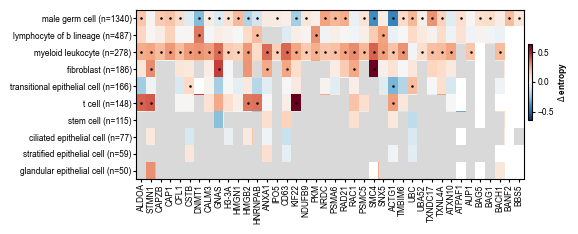

In [64]:
# Direction gate. `sig_dir` is the set of significant calls the chosen direction admits;
# everything downstream (ranking, the has_sig test, the top-40 cut) uses it, so a gene reaches
# the panel only if it has a significant call OF THAT DIRECTION in at least one class. The
# heatmap still draws each gene's effect in EVERY class, including classes where it moves the
# other way -- the filter selects rows, it does not censor cells.
if HEATMAP_DIRECTION == 'both':
    sig_dir = sig
elif HEATMAP_DIRECTION == 'up':
    sig_dir = sig & (eff > 0)
elif HEATMAP_DIRECTION == 'down':
    sig_dir = sig & (eff < 0)
else:
    raise ValueError(f"HEATMAP_DIRECTION must be 'both', 'up' or 'down', "
                     f"got {HEATMAP_DIRECTION!r}")
_dir_suffix = '' if HEATMAP_DIRECTION == 'both' else f'_{HEATMAP_DIRECTION}'
has_sig_dir = np.nansum(sig_dir, axis=0) > 0
print(f'direction filter: {HEATMAP_DIRECTION!r} -> '
      f'{int(has_sig_dir.sum()):,} of {int(has_sig.sum()):,} significant genes eligible '
      f'({int(np.nansum(sig_dir)):,} of {int(np.nansum(sig)):,} significant calls)')

top_genes = np.argsort(-np.nansum(sig_dir, axis=0))[:40]
top_genes = [g for g in top_genes if has_sig_dir[g]][:40]
if not len(top_genes):
    raise ValueError(f'no gene has a significant {HEATMAP_DIRECTION} call -- '
                     f'nothing to plot. Set HEATMAP_DIRECTION back to a wider setting.')
order = np.argsort([-sen_per_class[c] for c in classes])
M = eff[np.ix_(order, top_genes)]
S = sig[np.ix_(order, top_genes)]
U = (~S) & (mde[np.ix_(order, top_genes)] >= ref[top_genes]) & np.isfinite(M)
lim = np.nanmax(np.abs(M)) if np.isfinite(M).any() else 1.0

fig, ax = plt.subplots(figsize=(5.0, 0.13 * len(order) + 0.9))
im = ax.imshow(M, cmap='RdBu_r', vmin=-lim, vmax=lim, aspect='auto')
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        if U[i, j]:
            ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                                       facecolor=UNDERPOWERED_COLOR,
                                       edgecolor='none', zorder=2))
        elif S[i, j]:
            ax.plot(j, i, marker='.', ms=1.6, color='k', zorder=3)
ax.set_xticks(range(len(top_genes)))
ax.set_xticklabels([genes[g] for g in top_genes], rotation=90)
ax.set_yticks(range(len(order)))
ax.set_yticklabels([classes[i] + ' (n=' + str(int(sen_per_class[classes[i]])) + ')'
                    for i in order])
# ax.set_title('Entropy change by gene and cell class\n'
             # 'grey = class not powered to detect the effect; dot = BH < 0.05',
             # pad=PANEL_TITLE_PAD)
cax = ax.inset_axes([1.01, 0.35, 0.012, 0.45])
cb = fig.colorbar(im, cax=cax)
cb.set_label('$\\Delta$ entropy', fontsize=6)
cb.ax.tick_params(labelsize=6, length=TICK_LEN)
ax.tick_params(length=TICK_LEN, pad=TICK_LABEL_PAD)
fig.savefig(figpath(f'06_11_supp11e_heatmap_powered{_dir_suffix}.pdf'),
            bbox_inches='tight', dpi=300)
plt.show()

            broad_cell_class  n_sen                                     top_genes
              male germ cell   1340 SELENOP, ATP5MK, LINC00943, CFAP91, LINC01304
     lymphocyte of b lineage    487              DNMT1, PKM, EIF4G1, HNRNPR, SNX5
           myeloid leukocyte    278              CD36, CTSL, HSP90B1, POC1A, PRC1
                  fibroblast    186                PTTG1, SMC4, FBN1, CCDC80, FN1
transitional epithelial cell    166                       IER3, UBC, CSTB, S100A6
                      t cell    148               KIF22, DBF4, NASP, CKAP2, NOP56
                   stem cell    115                        (none significant, up)
    ciliated epithelial cell     77                                         METRN
  stratified epithelial cell     59                                        NFKBIA
   glandular epithelial cell     50                                    CAV1, ECI2

union of top-5 genes across 10 classes: 33
matrix (10, 33): 238 testable cells, 49 significant, 7

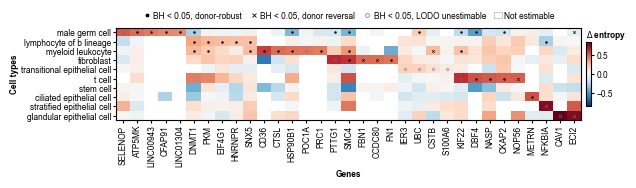

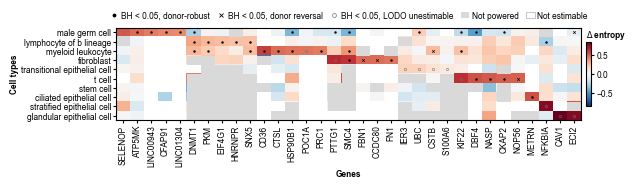


Reading: every cell that turns grey in the lower panel is one the upper
panel presents as a measured absence of change. That difference is the
whole of the "cell-type-restricted" claim.
of 49 significant cells shown: 33 donor-robust (67%), 5 with an observed donor reversal, 11 unresolved by leave-one-donor-out
The last two share no meaning: a reversal argues against the call, a lost estimate
says nothing either way. Quote them separately in the caption.


In [65]:

# Top genes per cell class, drawn twice as TWO SEPARATE FIGURES: as the published
# panel would look (no power information) and with underpowered cells greyed. Same
# genes, same row/column order and the same colour scale, so the ONLY difference
# between the two is what the power test reveals.
TOP_N = 5

order_cls = np.argsort([-sen_per_class[c] for c in classes])
sel, rows_top = [], []
for c in order_cls:
    # sig_dir, not sig: with HEATMAP_DIRECTION='up' a class contributes only the genes
    # whose entropy INCREASES in that class, so 'top five' is read within the direction.
    cand = np.where(testable[c] & sig_dir[c])[0]
    if cand.size == 0:
        rows_top.append({'broad_cell_class': classes[c],
                         'n_sen': int(sen_per_class[classes[c]]),
                         'top_genes': f'(none significant, {HEATMAP_DIRECTION})'})
        continue
    ordr = cand[np.argsort(-np.abs(eff[c][cand]))][:TOP_N]
    rows_top.append({'broad_cell_class': classes[c],
                     'n_sen': int(sen_per_class[classes[c]]),
                     'top_genes': ', '.join(genes[g] for g in ordr)})
    for g in ordr:
        if g not in sel:
            sel.append(g)          # grouped by the class they are top in
top_tab = pd.DataFrame(rows_top)
print(top_tab.to_string(index=False))
top_tab.to_csv(OUT + f'/06_11_top5_per_class{_dir_suffix}.csv', index=False)
print()
print(f'union of top-{TOP_N} genes across {n_cls} classes: {len(sel)}')

M = eff[np.ix_(order_cls, sel)]
S = sig[np.ix_(order_cls, sel)]
R = robust[np.ix_(order_cls, sel)]
# fragile too, so the three LODO outcomes can be drawn apart. `unresolved` needs no
# slice of its own: within the significant cells it is exactly S & ~R & ~F.
F = fragile[np.ix_(order_cls, sel)]
# underpowered: not significant, gene has a signal elsewhere, class could not
# have detected the effect seen where it was significant
U = ((~S) & np.isfinite(M)
     & (mde[np.ix_(order_cls, sel)] >= ref[sel])
     & has_sig[sel])
lim = float(np.nanmax(np.abs(M))) if np.isfinite(M).any() else 1.0
ylab = [classes[i] + ' (n=' + str(int(sen_per_class[classes[i]])) + ')'
        for i in order_cls]
ylab = [classes[i] for i in order_cls]
print(f'matrix {M.shape}: {int(np.isfinite(M).sum()):,} testable cells, '
      f'{int(S.sum()):,} significant, {int(U.sum()):,} underpowered '
      f'({100 * U.sum() / max(np.isfinite(M).sum(), 1):.0f}% of testable)')

cmap = plt.get_cmap('RdBu_r').copy()
cmap.set_bad('white')                     # NaN = not testable at all

# Two INDEPENDENT figures rather than stacked panels, so each can be placed on its own.
# Same M, same row/column order and the same vmin/vmax `lim` in both, so the colours stay
# directly comparable -- greying is the only difference. Each figure carries its own gene
# labels (there is no shared x axis to inherit them from any more) and its own colourbar,
# drawn in an inset cax so it does not steal width from the heatmap and leave the two
# figures at different sizes (see the colorbar gotcha in CLAUDE.md).
HEATMAP_PANELS = [
    ('no_power', False, 'as published: no power information'),
    ('with_power', True, 'with power test: grey = class not powered to detect it'),
]
for _slug, greyed, ttl in HEATMAP_PANELS:
    fig, ax = plt.subplots(figsize=(6.0,1.2))
    im = ax.imshow(np.ma.masked_invalid(M), cmap=cmap, vmin=-lim, vmax=lim,
                   aspect='auto', interpolation='nearest')
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            if greyed and U[i, j]:
                ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                                           facecolor=UNDERPOWERED_COLOR,
                                           edgecolor='none', zorder=2))
            elif S[i, j]:
                # THREE outcomes, not two. robust = no sign flip and estimable in every
                # leave-one-donor-out subset; fragile = a reversal was OBSERVED, which is
                # evidence AGAINST the call; unresolved = LODO lost estimability, which is
                # no evidence either way. The last two used to share one open circle, so
                # the panel read "half these calls do not replicate across donors" when
                # atlas-wide the observed reversals are 97 of 2,230 significant calls and
                # the unresolved ones 803 -- an ~8-fold overstatement, and one that says
                # power rather than donor-specificity, which is this panel's whole point.
                if R[i, j]:
                    ax.plot(j, i, marker='.', ms=1.5, color='k', zorder=3)
                elif F[i, j]:
                    ax.plot(j, i, marker='x', ms=1.8, color='k', mew=0.5, zorder=3)
                else:
                    ax.plot(j, i, marker='o', ms=1.6, mfc='none', mec='0.45',
                            mew=0.4, zorder=3)
    ax.set_yticks(range(len(order_cls)))
    ax.set_yticklabels(ylab)
    ax.set_xticks(range(len(sel)))
    ax.set_xticklabels([genes[g] for g in sel], rotation=90)
    ax.set_xlabel("Genes")
    ax.set_ylabel("Cell types")
    ax.tick_params(length=TICK_LEN, pad=TICK_LABEL_PAD)
    cax = ax.inset_axes([1.01, 0.15, 0.012, 0.70])
    cb = fig.colorbar(im, cax=cax)
    # cb.set_label('$\\Delta$ entropy', fontsize=6)
    cb.ax.set_title('$\\Delta$ entropy', fontsize=6, pad=2, loc='left')

    cb.ax.tick_params(labelsize=6, length=TICK_LEN)

    # Marker legend ABOVE the panel. Without it the symbols are unreadable: a filled dot
    # and an open circle at 1.5 pt differ by a few pixels, and grey-vs-white carries the
    # not-powered / not-estimable distinction that the whole figure exists to make.
    # Legend markers are drawn larger than the plotted ones deliberately -- at 1.5 pt a
    # legend key is a smudge. Handles are built per panel: `no_power` has no grey cells,
    # so listing "not powered" there would describe something absent from the figure.
    from matplotlib.lines import Line2D
    from matplotlib.patches import Patch
    _handles = [
        Line2D([], [], marker='.', ms=3.5, color='k', ls='none',
               label='BH < 0.05, donor-robust'),
        Line2D([], [], marker='x', ms=2.6, color='k', mew=0.6, ls='none',
               label='BH < 0.05, donor reversal'),
        Line2D([], [], marker='o', ms=2.8, mfc='none', mec='0.45', mew=0.5, ls='none',
               label='BH < 0.05, LODO unestimable'),
    ]
    if greyed:
        _handles.append(Patch(facecolor=UNDERPOWERED_COLOR, edgecolor='none',
                              label='Not powered'))
    _handles.append(Patch(facecolor='white', edgecolor='0.6', linewidth=0.4,
                          label='Not estimable'))
    ax.legend(handles=_handles, loc='lower center', bbox_to_anchor=(0.5, 1.02),
              ncol=len(_handles), frameon=False, handletextpad=0.3,
              columnspacing=0.9, borderpad=0.2, handlelength=1.0)
    # the two figures are otherwise identical, so the title is what tells them apart
    # ax.set_title('Top ' + str(TOP_N) + ' genes per cell class, ' + ttl + '\n'
    #              'filled dot = BH < 0.05 and donor-robust; open = donor-dependent',
    #              pad=PANEL_TITLE_PAD)
    fig.savefig(figpath('06_11_top5_' + _slug + _dir_suffix + '.pdf'),
                bbox_inches='tight', dpi=300)
    plt.show()
print()
print('Reading: every cell that turns grey in the lower panel is one the upper')
print('panel presents as a measured absence of change. That difference is the')
print('whole of the "cell-type-restricted" claim.')
_sig_n = int(S.sum())
_rob_n = int((S & R).sum())
_fra_n = int((S & F).sum())
_unr_n = _sig_n - _rob_n - _fra_n
print(f'of {_sig_n} significant cells shown: {_rob_n} donor-robust '
      f'({100 * _rob_n / max(_sig_n, 1):.0f}%), {_fra_n} with an observed donor reversal, '
      f'{_unr_n} unresolved by leave-one-donor-out')
print('The last two share no meaning: a reversal argues against the call, a lost estimate')
print('says nothing either way. Quote them separately in the caption.')
final['top5_direction'] = HEATMAP_DIRECTION
final['top5_n_genes'] = len(sel)
final['top5_pct_underpowered'] = float(100 * U.sum() / max(np.isfinite(M).sum(), 1))
final['top5_n_sig'] = _sig_n
final['top5_n_robust'] = _rob_n
final['top5_n_fragile'] = _fra_n
final['top5_n_unresolved'] = _unr_n

### Per-cell diversity distribution for one gene in one cell class


heatmap rows (first 15): ALDOA, STMN1, CAPZB, CAP1, CFL1, CSTB, DNMT1, CALM3, GNAS, H3-3A, HMGN1, HMGB2, HNRNPAB, ANXA1, IPO5

Gene FN1 | class fibroblast | 23 isoforms
  heatmap cell: effect +0.4649  se 0.1171  BH 0.0336  SIGNIFICANT
                MDE 0.3280 at 80% power; leave-one-donor-out: robust
                186 senescent cells in this class overall
donor gate 'match_volcano' (EXPRESSING >= 10 per arm; >=2-isoform filter OFF, drawability floor 1): 4 of 4 -> ['TSP21', 'TSP25', 'TSP27', 'TSP33']


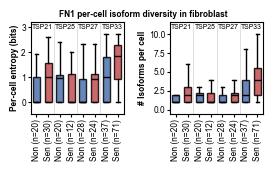


FN1 in fibroblast -- per-cell isoform diversity, sen vs non

donor       n_non  n_sen  medH_non  medH_sen    d_med  meanH_non  meanH_sen   d_mean  iso_non  iso_sen
TSP21          20     30     0.000     1.000   +1.000      0.346      1.019   +0.673      1.0      2.0
TSP25          20     12     0.959     0.000   -0.959      0.780      0.612   -0.168      2.0      1.0
TSP27          28     24     0.000     0.918   +0.918      0.434      0.773   +0.339      1.0      2.0
TSP33          37     71     1.000     1.842   +0.842      1.141      1.515   +0.374      2.0      4.0

higher in senescent cells: 3/4 donors by median, 3/4 by mean
H = per-cell Shannon entropy (bits) over this gene's isoform fractions, across cells
    with >= 2 isoforms detected. iso_* = median isoforms per expressing cell.
    Not corrected for library size -- this notebook does not stratify on depth.


In [82]:
# Per-cell isoform-diversity DISTRIBUTION for ONE gene in ONE cell class, split by donor
# (senescent vs non-senescent). Ported from 06_10b section 7.
#
# WIRED TO THIS NOTEBOOK'S OBJECTS, not 06_10b's: frac / genes / gene_of_iso / sen / cls_all /
# donor_arr all come from the accumulation cell, and eff / se / padj / sig / mde / robust come
# from sections 2-3, so this opens one cell of the heatmap above rather than recomputing it.
#
# THE TWO PANELS DESCRIBE DIFFERENT CELL SETS:
#   left  (entropy)       -- only cells with >= 2 isoforms of the gene; entropy is undefined at 1
#   right (isoform count) -- every cell of the class expressing the gene, 1-isoform cells included
SELECTED_GENE = "FN1"          # any gene symbol; the heatmap's rows are genes[top_genes]
SELECTED_CELLTYPE = "fibroblast"   # a broad_cell_class; None -> auto-pick (see below)
# 5, not MIN_CELLS_PER_ARM: this floor is PER DONOR, while the notebook's MIN_CELLS_PER_ARM = 10
# is per arm for the WHOLE class. A class can therefore be estimable in section 3 while no single
# donor clears the bar here; that is a statement about donor coverage, not a contradiction.
# MIN_CELLS_PER_GROUP now comes from the config cell.

# `genes` holds SYMBOLS in this notebook, so no ENSG lookup is needed -- but fail loudly with
# candidates rather than an opaque IndexError.
_hit = np.where(genes == SELECTED_GENE)[0]
if not len(_hit):
    _near = [g for g in genes if g.upper().startswith(SELECTED_GENE[:3].upper())][:12]
    raise ValueError(f"{SELECTED_GENE!r} is not in `genes`. Nearby: {_near}")
g_idx = int(_hit[0])
_label = SELECTED_GENE
iso_idx = np.where(gene_of_iso == g_idx)[0]

if 'top_genes' in dir():
    print('heatmap rows (first 15):', ', '.join(map(str, genes[top_genes][:15])))

# this gene's isoform fractions -> per-cell entropy + per-cell #expressed isoforms
GF = np.asarray(frac[:, iso_idx].todense()) if issparse(frac) else np.asarray(frac[:, iso_idx])
nz = GF > 0
n_iso_cell = nz.sum(axis=1)
with np.errstate(divide="ignore", invalid="ignore"):
    term_g = np.where(nz, -GF * np.log2(np.maximum(GF, 1e-300)), 0.0)
ent_cell = np.where(n_iso_cell >= 1, term_g.sum(axis=1), np.nan)   # defined only for >=1 isoforms
expressed = GF.sum(axis=1) > 0

sen_mask = sen
non_mask = ~sen
bcc_arr = cls_all


def _min_expr(ct):
    m = bcc_arr == ct
    return min(int((sen_mask & m & (n_iso_cell >= 2)).sum()),
               int((non_mask & m & (n_iso_cell >= 2)).sum()))


# AUTO-PICK differs from 06_10b's. There the best-populated class was the only sensible default;
# here the notebook already knows where this gene actually changed, so the default is the most
# significant ANALYSED class, falling back to best-populated if the gene is significant nowhere.
if SELECTED_CELLTYPE is None:
    _cand_sig = [(padj[cls_idx[c], g_idx], c) for c in classes
                 if np.isfinite(padj[cls_idx[c], g_idx])]
    if _cand_sig:
        SELECTED_CELLTYPE = min(_cand_sig)[1]
        print(f"Auto-selected cell class: {SELECTED_CELLTYPE} "
              f"(smallest BH p for this gene: {min(_cand_sig)[0]:.3g})")
    else:
        _cand = [c for c in pd.unique(bcc_arr) if c != "unknown"]
        SELECTED_CELLTYPE = max(_cand, key=_min_expr)
        print(f"Auto-selected cell class: {SELECTED_CELLTYPE} (not testable for this gene; "
              f"picked the best-populated, min sen/non cells with >=2 iso = "
              f"{_min_expr(SELECTED_CELLTYPE)})")

ct_mask = bcc_arr == SELECTED_CELLTYPE
donors_all = list(don_list)

# --- what the heatmap says about this (gene, class) --------------------------------------
print(f"\nGene {_label} | class {SELECTED_CELLTYPE} | {len(iso_idx)} isoforms")
if SELECTED_CELLTYPE in cls_idx:
    _c = cls_idx[SELECTED_CELLTYPE]
    if testable[_c, g_idx]:
        _verdict = ('robust' if robust[_c, g_idx] else
                    'FRAGILE (a LODO subset reversed the sign)' if fragile[_c, g_idx] else
                    'unresolved (LODO lost estimability)')
        print(f"  heatmap cell: effect {eff[_c, g_idx]:+.4f}  se {se[_c, g_idx]:.4f}  "
              f"BH {padj[_c, g_idx]:.3g}  {'SIGNIFICANT' if sig[_c, g_idx] else 'n.s.'}")
        print(f"                MDE {mde[_c, g_idx]:.4f} at 80% power; "
              f"leave-one-donor-out: {_verdict}")
        print(f"                {int(sen_per_class[SELECTED_CELLTYPE]):,} senescent cells in "
              f"this class overall")
    else:
        # The heatmap gate is applied to the UNCONDITIONAL denominator `nn` (cells
        # EXPRESSING the gene, >= 1 isoform), not to >= 2-isoform cells. The old
        # wording here said ">=2 isoforms" and dated from when this notebook was
        # conditional; it overstated how restrictive the heatmap is. The >= 2 rule
        # applies to the BOXES below, where a 1-isoform cell would be a point mass
        # at entropy 0 -- which is why a gene can have a heatmap cell here and still
        # be unplottable underneath.
        print(f"  NOT estimable in this class: one arm holds < MIN_CELLS_PER_ARM="
              f"{MIN_CELLS_PER_ARM} cells EXPRESSING this gene (>= 1 isoform).")
else:
    print(f"  class NOT analysed by this notebook (< MIN_SEN_PER_CLASS={MIN_SEN_PER_CLASS} "
          "senescent cells), so it has no heatmap row. The boxes below still draw.")


# entropy-defined cells (>=2 isoforms of this gene) per (donor, group)
def _n_ent(mask):
    return int((~np.isnan(ent_cell[mask])).sum())


# DONOR GATE, shared rule with 06_11. A donor is drawn only if it BOTH
#   (a) contributed to the test -- >= MIN_EXPR_CELLS_PER_GROUP cells EXPRESSING the gene
#       per arm, the same population the estimator's denominator counts, and
#   (b) is drawable -- >= MIN_CELLS_PER_GROUP cells with >= 2 isoforms per arm, since the
#       boxes plot an entropy distribution and a 1-isoform cell is a point mass at 0.
# Either test alone is defensible but they answer different questions, and the two
# notebooks used to apply a different one each, so a donor could appear in one panel and
# not the other. 'both' is the conjunction; the single-criterion options are kept so the
# old behaviour is reproducible.
def _n_expr(mask):
    return int((mask & (n_iso_cell >= 1)).sum())


def _donor_ok(d):
    _dm = ct_mask & (donor_arr == d)
    _e = min(_n_expr(non_mask & _dm), _n_expr(sen_mask & _dm))
    _f = min(_n_ent(non_mask & _dm), _n_ent(sen_mask & _dm))
    if DONOR_GATE == 'both':
        return _e >= MIN_EXPR_CELLS_PER_GROUP and _f >= MIN_CELLS_PER_GROUP
    if DONOR_GATE == 'match_volcano':
        # PLOTTABILITY FLOOR, not a filter. A donor with zero cells in which entropy is
        # DEFINED contributes an empty dataset to ax.boxplot, which raises
        # "List of boxplot statistics and `positions` values must have same the length".
        # >= 1 is the minimum that can be drawn at all; it is not a power threshold.
        return _e >= MIN_EXPR_CELLS_PER_GROUP and _f >= 1
    if DONOR_GATE == 'entropy_defined':
        return _f >= MIN_CELLS_PER_GROUP
    raise ValueError(f"DONOR_GATE must be 'both', 'match_volcano' or "
                     f"'entropy_defined', got {DONOR_GATE!r}")


donors_shown = [d for d in donors_all if _donor_ok(d)]
# Describe the criteria ACTUALLY applied. The previous wording said "EXPRESSING >= 10
# and/or >=2-isoform >= 5" whatever DONOR_GATE was set to, so under match_volcano it
# advertised a >=2-isoform threshold of 5 that is not applied (the floor is 1, and only
# so the box can be drawn).
if DONOR_GATE == 'both':
    _gate_desc = (f"EXPRESSING >= {MIN_EXPR_CELLS_PER_GROUP} AND "
                  f">=2-isoform >= {MIN_CELLS_PER_GROUP}, per arm")
elif DONOR_GATE == 'match_volcano':
    _gate_desc = (f"EXPRESSING >= {MIN_EXPR_CELLS_PER_GROUP} per arm; >=2-isoform "
                  f"filter OFF, drawability floor 1")
else:
    _gate_desc = f">=2-isoform >= {MIN_CELLS_PER_GROUP}, per arm"
print(f"donor gate {DONOR_GATE!r} ({_gate_desc}): "
      f"{len(donors_shown)} of {len(donors_all)} -> {donors_shown}")
if 0 < len(donors_shown) < 2:
    print("  *** SINGLE-DONOR PANEL: the per-donor layout exists to show whether the\n"
          "      effect reproduces across donors, which one donor cannot do. Read it as\n"
          "      an illustration, not as evidence of reproducibility.")

# collect per (donor, group): entropy values + #isoforms among expressing cells
ent_data, iso_data, labels, grp = [], [], [], []
for d in donors_shown:
    dm = donor_arr == d
    for glab, gm in [("Non", non_mask), ("Sen", sen_mask)]:
        sel = gm & ct_mask & dm
        e = ent_cell[sel]; e = e[~np.isnan(e)]
        k = n_iso_cell[sel & expressed]
        ent_data.append(e); iso_data.append(k); grp.append(glab)
        labels.append(f"{glab} (n={len(e)})")      # donor name goes above the pair instead
colors = [DOWN_COLOR if g == "Non" else UP_COLOR for g in grp]

# Guard: nothing to plot. With no qualifying donor, labels/ent_data are empty and
# pos = np.arange(0); matplotlib's _reshape_2D([]) then returns a SINGLE empty dataset (N=1)
# while positions has length 0, so ax.boxplot raises "List of boxplot statistics and
# `positions` values must have same the length". Skip plotting rather than fall through --
# an empty plot must never overwrite a mapped panel on disk.
if len(donors_shown) == 0:
    # Report WHICH test each donor failed. Under DONOR_GATE = 'both' a donor can fail
    # on the EXPRESSING count, on the >=2-isoform count, or on both, and the old message
    # named only the second -- so a failure of the first read as the wrong diagnosis.
    _fail_e = _fail_f = _fail_both = 0
    for _d in donors_all:
        _dm2 = ct_mask & (donor_arr == _d)
        _e2 = min(_n_expr(non_mask & _dm2), _n_expr(sen_mask & _dm2))
        _f2 = min(_n_ent(non_mask & _dm2), _n_ent(sen_mask & _dm2))
        _be = _e2 < MIN_EXPR_CELLS_PER_GROUP
        _thr_f = MIN_CELLS_PER_GROUP if DONOR_GATE in ('both', 'entropy_defined') else 1
        _bf = _f2 < _thr_f
        if _be and _bf:
            _fail_both += 1
        elif _be:
            _fail_e += 1
        elif _bf:
            _fail_f += 1
    print(f"\nNothing to plot for {_label} in {SELECTED_CELLTYPE}: no donor passed "
          f"DONOR_GATE={DONOR_GATE!r}.")
    print(f"  failed the EXPRESSING test only (< {MIN_EXPR_CELLS_PER_GROUP} per arm) : "
          f"{_fail_e} donor(s)")
    print(f"  failed the >=2-isoform test only (< {_thr_f} per arm): "
          f"{_fail_f} donor(s)")
    print(f"  failed both                                              : "
          f"{_fail_both} donor(s)")
    print("Per-donor cells with >=2 isoforms of this gene (non-senescent / senescent):")
    for _d in donors_all:
        _dm = donor_arr == _d
        print(f"   {_d:>10s}: {_n_ent(non_mask & ct_mask & _dm):6d} / "
              f"{_n_ent(sen_mask & ct_mask & _dm):6d}")
    print(f"   cells expressing this gene at all in {SELECTED_CELLTYPE}: "
          f"{int((expressed & ct_mask & non_mask).sum())} non / "
          f"{int((expressed & ct_mask & sen_mask).sum())} sen")
    print("\nOptions: lower MIN_CELLS_PER_GROUP, choose another class (SELECTED_CELLTYPE=None\n"
          "auto-picks the class where this gene is most significant), or pick a gene with\n"
          "broader coverage -- the heatmap's rows are ordered by how many classes they change in.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(3.0, 1.2))
    pos = np.arange(len(labels))
    donor_xpos = pos[0::2] + 0.5   # midpoint of each (Non, Sen) pair -> one x per donor
    for ax, data, ylab in [
            (axes[0], ent_data, "Per-cell entropy (bits)"),
            (axes[1], iso_data, "# Isoforms per cell")]:
        safe = [np.asarray(d, float) if len(d) else np.array([np.nan]) for d in data]
        bp = ax.boxplot(safe, positions=pos, widths=0.6, showfliers=False, patch_artist=True)
        for patch, c in zip(bp["boxes"], colors):
            patch.set_facecolor(c); patch.set_alpha(0.85)
        for med in bp["medians"]:
            med.set_color("black")
        for k in range(2, len(pos), 2):
            ax.axvline(k - 0.5, color="black", alpha=0.15, linewidth=0.6)
        ax.set_xticks(pos); ax.set_xticklabels(labels, rotation=90)
        ax.set_ylabel(ylab)
        ax.tick_params(length=TICK_LEN, pad=TICK_LABEL_PAD)
        # donor names, inside the axes, above each (Non, Sen) pair
        ax.margins(y=0.18)                     # headroom so labels clear the tallest whisker
        trans = ax.get_xaxis_transform()       # x = data coords, y = axes-fraction (0-1)
        for xk, dn in zip(donor_xpos, donors_shown):
            ax.text(xk, 0.98, dn, transform=trans, ha="center", va="top", fontsize=5)
    fig.suptitle(f"{_label} per-cell isoform diversity in {SELECTED_CELLTYPE}")
    plt.subplots_adjust(wspace=0.50)
    # 06_11_ prefix and the gene/class in the name, NOT 06_10b's shared basename: that one is
    # 06_03_selected_gene_percell_entropy_by_donor.pdf and writing it from here would overwrite
    # a mapped panel. New basenames are not in FIG_MAP, so they land in figures/ root.
    _slug = f"{_label}_{SELECTED_CELLTYPE}".replace(' ', '_').replace('/', '-')
    plt.savefig(figpath(f"06_11_{_slug}_percell_entropy_by_donor.pdf"),
                bbox_inches="tight", dpi=300)
    plt.show()

    # --- effect sizes behind the panel ----------------------------------------------------
    # ent_data / iso_data are ordered [donor0 Non, donor0 Sen, donor1 Non, donor1 Sen, ...].
    # MEDIAN and MEAN are both printed because they routinely disagree in sign: per-cell
    # entropy is skewed and bounded below, so a shift in the right tail moves the mean while
    # the median stays put. The heatmap's `effect` is a difference of MEANS, so the mean
    # column is the one that reconciles with the number printed above.
    print(f"\n{_label} in {SELECTED_CELLTYPE} -- per-cell isoform diversity, sen vs non\n")
    print(f"{'donor':10s} {'n_non':>6s} {'n_sen':>6s} {'medH_non':>9s} {'medH_sen':>9s} "
          f"{'d_med':>8s} {'meanH_non':>10s} {'meanH_sen':>10s} {'d_mean':>8s} "
          f"{'iso_non':>8s} {'iso_sen':>8s}")
    _up_med = _up_mean = 0
    for _i, _d in enumerate(donors_shown):
        e_non, e_sen = ent_data[2 * _i], ent_data[2 * _i + 1]
        k_non, k_sen = iso_data[2 * _i], iso_data[2 * _i + 1]
        h_non, h_sen = float(np.median(e_non)), float(np.median(e_sen))
        a_non, a_sen = float(np.mean(e_non)), float(np.mean(e_sen))
        _up_med += int(h_sen > h_non)
        _up_mean += int(a_sen > a_non)
        print(f"{_d:10s} {len(e_non):6d} {len(e_sen):6d} {h_non:9.3f} {h_sen:9.3f} "
              f"{h_sen - h_non:+8.3f} {a_non:10.3f} {a_sen:10.3f} {a_sen - a_non:+8.3f} "
              f"{np.median(k_non):8.1f} {np.median(k_sen):8.1f}")
    print(f"\nhigher in senescent cells: {_up_med}/{len(donors_shown)} donors by median, "
          f"{_up_mean}/{len(donors_shown)} by mean")
    print("H = per-cell Shannon entropy (bits) over this gene's isoform fractions, across cells")
    print("    with >= 2 isoforms detected. iso_* = median isoforms per expressing cell.")
    print("    Not corrected for library size -- this notebook does not stratify on depth.")

heatmap rows (first 15): ALDOA, STMN1, CAPZB, CAP1, CFL1, CSTB, DNMT1, CALM3, GNAS, H3-3A, HMGN1, HMGB2, HNRNPAB, ANXA1, IPO5

Gene CTSL | class myeloid leukocyte | 38 isoforms
  heatmap cell: effect +0.4825  se 0.0861  BH 4.67e-06  SIGNIFICANT
                MDE 0.2412 at 80% power; leave-one-donor-out: robust
                278 senescent cells in this class overall
donor gate 'match_volcano' (EXPRESSING >= 10 per arm; >=2-isoform filter OFF, drawability floor 1): 3 of 4 -> ['TSP21', 'TSP25', 'TSP33']


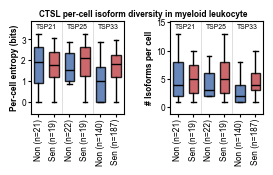


CTSL in myeloid leukocyte -- per-cell isoform diversity, sen vs non

donor       n_non  n_sen  medH_non  medH_sen    d_med  meanH_non  meanH_sen   d_mean  iso_non  iso_sen
TSP21          21     19     1.922     1.780   -0.142      1.702      1.768   +0.066      4.0      5.0
TSP25          22     19     1.522     2.118   +0.596      1.695      1.862   +0.167      3.0      5.0
TSP33         140    187     1.000     1.792   +0.792      1.041      1.669   +0.628      2.0      4.0

higher in senescent cells: 2/3 donors by median, 3/3 by mean
H = per-cell Shannon entropy (bits) over this gene's isoform fractions, across cells
    with >= 2 isoforms detected. iso_* = median isoforms per expressing cell.
    Not corrected for library size -- this notebook does not stratify on depth.


In [81]:
# Per-cell isoform-diversity DISTRIBUTION for ONE gene in ONE cell class, split by donor
# (senescent vs non-senescent). Ported from 06_10b section 7.
#
# WIRED TO THIS NOTEBOOK'S OBJECTS, not 06_10b's: frac / genes / gene_of_iso / sen / cls_all /
# donor_arr all come from the accumulation cell, and eff / se / padj / sig / mde / robust come
# from sections 2-3, so this opens one cell of the heatmap above rather than recomputing it.
#
# THE TWO PANELS DESCRIBE DIFFERENT CELL SETS:
#   left  (entropy)       -- only cells with >= 2 isoforms of the gene; entropy is undefined at 1
#   right (isoform count) -- every cell of the class expressing the gene, 1-isoform cells included
SELECTED_GENE = "CTSL"          # any gene symbol; the heatmap's rows are genes[top_genes]
SELECTED_CELLTYPE = "myeloid leukocyte"   # a broad_cell_class; None -> auto-pick (see below)
# 5, not MIN_CELLS_PER_ARM: this floor is PER DONOR, while the notebook's MIN_CELLS_PER_ARM = 10
# is per arm for the WHOLE class. A class can therefore be estimable in section 3 while no single
# donor clears the bar here; that is a statement about donor coverage, not a contradiction.
# MIN_CELLS_PER_GROUP now comes from the config cell.

# `genes` holds SYMBOLS in this notebook, so no ENSG lookup is needed -- but fail loudly with
# candidates rather than an opaque IndexError.
_hit = np.where(genes == SELECTED_GENE)[0]
if not len(_hit):
    _near = [g for g in genes if g.upper().startswith(SELECTED_GENE[:3].upper())][:12]
    raise ValueError(f"{SELECTED_GENE!r} is not in `genes`. Nearby: {_near}")
g_idx = int(_hit[0])
_label = SELECTED_GENE
iso_idx = np.where(gene_of_iso == g_idx)[0]

if 'top_genes' in dir():
    print('heatmap rows (first 15):', ', '.join(map(str, genes[top_genes][:15])))

# this gene's isoform fractions -> per-cell entropy + per-cell #expressed isoforms
GF = np.asarray(frac[:, iso_idx].todense()) if issparse(frac) else np.asarray(frac[:, iso_idx])
nz = GF > 0
n_iso_cell = nz.sum(axis=1)
with np.errstate(divide="ignore", invalid="ignore"):
    term_g = np.where(nz, -GF * np.log2(np.maximum(GF, 1e-300)), 0.0)
ent_cell = np.where(n_iso_cell >= 1, term_g.sum(axis=1), np.nan)   # defined only for >=1 isoforms
expressed = GF.sum(axis=1) > 0

sen_mask = sen
non_mask = ~sen
bcc_arr = cls_all


def _min_expr(ct):
    m = bcc_arr == ct
    return min(int((sen_mask & m & (n_iso_cell >= 2)).sum()),
               int((non_mask & m & (n_iso_cell >= 2)).sum()))


# AUTO-PICK differs from 06_10b's. There the best-populated class was the only sensible default;
# here the notebook already knows where this gene actually changed, so the default is the most
# significant ANALYSED class, falling back to best-populated if the gene is significant nowhere.
if SELECTED_CELLTYPE is None:
    _cand_sig = [(padj[cls_idx[c], g_idx], c) for c in classes
                 if np.isfinite(padj[cls_idx[c], g_idx])]
    if _cand_sig:
        SELECTED_CELLTYPE = min(_cand_sig)[1]
        print(f"Auto-selected cell class: {SELECTED_CELLTYPE} "
              f"(smallest BH p for this gene: {min(_cand_sig)[0]:.3g})")
    else:
        _cand = [c for c in pd.unique(bcc_arr) if c != "unknown"]
        SELECTED_CELLTYPE = max(_cand, key=_min_expr)
        print(f"Auto-selected cell class: {SELECTED_CELLTYPE} (not testable for this gene; "
              f"picked the best-populated, min sen/non cells with >=2 iso = "
              f"{_min_expr(SELECTED_CELLTYPE)})")

ct_mask = bcc_arr == SELECTED_CELLTYPE
donors_all = list(don_list)

# --- what the heatmap says about this (gene, class) --------------------------------------
print(f"\nGene {_label} | class {SELECTED_CELLTYPE} | {len(iso_idx)} isoforms")
if SELECTED_CELLTYPE in cls_idx:
    _c = cls_idx[SELECTED_CELLTYPE]
    if testable[_c, g_idx]:
        _verdict = ('robust' if robust[_c, g_idx] else
                    'FRAGILE (a LODO subset reversed the sign)' if fragile[_c, g_idx] else
                    'unresolved (LODO lost estimability)')
        print(f"  heatmap cell: effect {eff[_c, g_idx]:+.4f}  se {se[_c, g_idx]:.4f}  "
              f"BH {padj[_c, g_idx]:.3g}  {'SIGNIFICANT' if sig[_c, g_idx] else 'n.s.'}")
        print(f"                MDE {mde[_c, g_idx]:.4f} at 80% power; "
              f"leave-one-donor-out: {_verdict}")
        print(f"                {int(sen_per_class[SELECTED_CELLTYPE]):,} senescent cells in "
              f"this class overall")
    else:
        # The heatmap gate is applied to the UNCONDITIONAL denominator `nn` (cells
        # EXPRESSING the gene, >= 1 isoform), not to >= 2-isoform cells. The old
        # wording here said ">=2 isoforms" and dated from when this notebook was
        # conditional; it overstated how restrictive the heatmap is. The >= 2 rule
        # applies to the BOXES below, where a 1-isoform cell would be a point mass
        # at entropy 0 -- which is why a gene can have a heatmap cell here and still
        # be unplottable underneath.
        print(f"  NOT estimable in this class: one arm holds < MIN_CELLS_PER_ARM="
              f"{MIN_CELLS_PER_ARM} cells EXPRESSING this gene (>= 1 isoform).")
else:
    print(f"  class NOT analysed by this notebook (< MIN_SEN_PER_CLASS={MIN_SEN_PER_CLASS} "
          "senescent cells), so it has no heatmap row. The boxes below still draw.")


# entropy-defined cells (>=2 isoforms of this gene) per (donor, group)
def _n_ent(mask):
    return int((~np.isnan(ent_cell[mask])).sum())


# DONOR GATE, shared rule with 06_11. A donor is drawn only if it BOTH
#   (a) contributed to the test -- >= MIN_EXPR_CELLS_PER_GROUP cells EXPRESSING the gene
#       per arm, the same population the estimator's denominator counts, and
#   (b) is drawable -- >= MIN_CELLS_PER_GROUP cells with >= 2 isoforms per arm, since the
#       boxes plot an entropy distribution and a 1-isoform cell is a point mass at 0.
# Either test alone is defensible but they answer different questions, and the two
# notebooks used to apply a different one each, so a donor could appear in one panel and
# not the other. 'both' is the conjunction; the single-criterion options are kept so the
# old behaviour is reproducible.
def _n_expr(mask):
    return int((mask & (n_iso_cell >= 1)).sum())


def _donor_ok(d):
    _dm = ct_mask & (donor_arr == d)
    _e = min(_n_expr(non_mask & _dm), _n_expr(sen_mask & _dm))
    _f = min(_n_ent(non_mask & _dm), _n_ent(sen_mask & _dm))
    if DONOR_GATE == 'both':
        return _e >= MIN_EXPR_CELLS_PER_GROUP and _f >= MIN_CELLS_PER_GROUP
    if DONOR_GATE == 'match_volcano':
        # PLOTTABILITY FLOOR, not a filter. A donor with zero cells in which entropy is
        # DEFINED contributes an empty dataset to ax.boxplot, which raises
        # "List of boxplot statistics and `positions` values must have same the length".
        # >= 1 is the minimum that can be drawn at all; it is not a power threshold.
        return _e >= MIN_EXPR_CELLS_PER_GROUP and _f >= 1
    if DONOR_GATE == 'entropy_defined':
        return _f >= MIN_CELLS_PER_GROUP
    raise ValueError(f"DONOR_GATE must be 'both', 'match_volcano' or "
                     f"'entropy_defined', got {DONOR_GATE!r}")


donors_shown = [d for d in donors_all if _donor_ok(d)]
# Describe the criteria ACTUALLY applied. The previous wording said "EXPRESSING >= 10
# and/or >=2-isoform >= 5" whatever DONOR_GATE was set to, so under match_volcano it
# advertised a >=2-isoform threshold of 5 that is not applied (the floor is 1, and only
# so the box can be drawn).
if DONOR_GATE == 'both':
    _gate_desc = (f"EXPRESSING >= {MIN_EXPR_CELLS_PER_GROUP} AND "
                  f">=2-isoform >= {MIN_CELLS_PER_GROUP}, per arm")
elif DONOR_GATE == 'match_volcano':
    _gate_desc = (f"EXPRESSING >= {MIN_EXPR_CELLS_PER_GROUP} per arm; >=2-isoform "
                  f"filter OFF, drawability floor 1")
else:
    _gate_desc = f">=2-isoform >= {MIN_CELLS_PER_GROUP}, per arm"
print(f"donor gate {DONOR_GATE!r} ({_gate_desc}): "
      f"{len(donors_shown)} of {len(donors_all)} -> {donors_shown}")
if 0 < len(donors_shown) < 2:
    print("  *** SINGLE-DONOR PANEL: the per-donor layout exists to show whether the\n"
          "      effect reproduces across donors, which one donor cannot do. Read it as\n"
          "      an illustration, not as evidence of reproducibility.")

# collect per (donor, group): entropy values + #isoforms among expressing cells
ent_data, iso_data, labels, grp = [], [], [], []
for d in donors_shown:
    dm = donor_arr == d
    for glab, gm in [("Non", non_mask), ("Sen", sen_mask)]:
        sel = gm & ct_mask & dm
        e = ent_cell[sel]; e = e[~np.isnan(e)]
        k = n_iso_cell[sel & expressed]
        ent_data.append(e); iso_data.append(k); grp.append(glab)
        labels.append(f"{glab} (n={len(e)})")      # donor name goes above the pair instead
colors = [DOWN_COLOR if g == "Non" else UP_COLOR for g in grp]

# Guard: nothing to plot. With no qualifying donor, labels/ent_data are empty and
# pos = np.arange(0); matplotlib's _reshape_2D([]) then returns a SINGLE empty dataset (N=1)
# while positions has length 0, so ax.boxplot raises "List of boxplot statistics and
# `positions` values must have same the length". Skip plotting rather than fall through --
# an empty plot must never overwrite a mapped panel on disk.
if len(donors_shown) == 0:
    # Report WHICH test each donor failed. Under DONOR_GATE = 'both' a donor can fail
    # on the EXPRESSING count, on the >=2-isoform count, or on both, and the old message
    # named only the second -- so a failure of the first read as the wrong diagnosis.
    _fail_e = _fail_f = _fail_both = 0
    for _d in donors_all:
        _dm2 = ct_mask & (donor_arr == _d)
        _e2 = min(_n_expr(non_mask & _dm2), _n_expr(sen_mask & _dm2))
        _f2 = min(_n_ent(non_mask & _dm2), _n_ent(sen_mask & _dm2))
        _be = _e2 < MIN_EXPR_CELLS_PER_GROUP
        _thr_f = MIN_CELLS_PER_GROUP if DONOR_GATE in ('both', 'entropy_defined') else 1
        _bf = _f2 < _thr_f
        if _be and _bf:
            _fail_both += 1
        elif _be:
            _fail_e += 1
        elif _bf:
            _fail_f += 1
    print(f"\nNothing to plot for {_label} in {SELECTED_CELLTYPE}: no donor passed "
          f"DONOR_GATE={DONOR_GATE!r}.")
    print(f"  failed the EXPRESSING test only (< {MIN_EXPR_CELLS_PER_GROUP} per arm) : "
          f"{_fail_e} donor(s)")
    print(f"  failed the >=2-isoform test only (< {_thr_f} per arm): "
          f"{_fail_f} donor(s)")
    print(f"  failed both                                              : "
          f"{_fail_both} donor(s)")
    print("Per-donor cells with >=2 isoforms of this gene (non-senescent / senescent):")
    for _d in donors_all:
        _dm = donor_arr == _d
        print(f"   {_d:>10s}: {_n_ent(non_mask & ct_mask & _dm):6d} / "
              f"{_n_ent(sen_mask & ct_mask & _dm):6d}")
    print(f"   cells expressing this gene at all in {SELECTED_CELLTYPE}: "
          f"{int((expressed & ct_mask & non_mask).sum())} non / "
          f"{int((expressed & ct_mask & sen_mask).sum())} sen")
    print("\nOptions: lower MIN_CELLS_PER_GROUP, choose another class (SELECTED_CELLTYPE=None\n"
          "auto-picks the class where this gene is most significant), or pick a gene with\n"
          "broader coverage -- the heatmap's rows are ordered by how many classes they change in.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(3.0, 1.2))
    pos = np.arange(len(labels))
    donor_xpos = pos[0::2] + 0.5   # midpoint of each (Non, Sen) pair -> one x per donor
    for ax, data, ylab in [
            (axes[0], ent_data, "Per-cell entropy (bits)"),
            (axes[1], iso_data, "# Isoforms per cell")]:
        safe = [np.asarray(d, float) if len(d) else np.array([np.nan]) for d in data]
        bp = ax.boxplot(safe, positions=pos, widths=0.6, showfliers=False, patch_artist=True)
        for patch, c in zip(bp["boxes"], colors):
            patch.set_facecolor(c); patch.set_alpha(0.85)
        for med in bp["medians"]:
            med.set_color("black")
        for k in range(2, len(pos), 2):
            ax.axvline(k - 0.5, color="black", alpha=0.15, linewidth=0.6)
        ax.set_xticks(pos); ax.set_xticklabels(labels, rotation=90)
        ax.set_ylabel(ylab)
        ax.tick_params(length=TICK_LEN, pad=TICK_LABEL_PAD)
        # donor names, inside the axes, above each (Non, Sen) pair
        ax.margins(y=0.18)                     # headroom so labels clear the tallest whisker
        trans = ax.get_xaxis_transform()       # x = data coords, y = axes-fraction (0-1)
        for xk, dn in zip(donor_xpos, donors_shown):
            ax.text(xk, 0.98, dn, transform=trans, ha="center", va="top", fontsize=5)
    fig.suptitle(f"{_label} per-cell isoform diversity in {SELECTED_CELLTYPE}")
    plt.subplots_adjust(wspace=0.50)
    # 06_11_ prefix and the gene/class in the name, NOT 06_10b's shared basename: that one is
    # 06_03_selected_gene_percell_entropy_by_donor.pdf and writing it from here would overwrite
    # a mapped panel. New basenames are not in FIG_MAP, so they land in figures/ root.
    _slug = f"{_label}_{SELECTED_CELLTYPE}".replace(' ', '_').replace('/', '-')
    plt.savefig(figpath(f"06_11_{_slug}_percell_entropy_by_donor.pdf"),
                bbox_inches="tight", dpi=300)
    plt.show()

    # --- effect sizes behind the panel ----------------------------------------------------
    # ent_data / iso_data are ordered [donor0 Non, donor0 Sen, donor1 Non, donor1 Sen, ...].
    # MEDIAN and MEAN are both printed because they routinely disagree in sign: per-cell
    # entropy is skewed and bounded below, so a shift in the right tail moves the mean while
    # the median stays put. The heatmap's `effect` is a difference of MEANS, so the mean
    # column is the one that reconciles with the number printed above.
    print(f"\n{_label} in {SELECTED_CELLTYPE} -- per-cell isoform diversity, sen vs non\n")
    print(f"{'donor':10s} {'n_non':>6s} {'n_sen':>6s} {'medH_non':>9s} {'medH_sen':>9s} "
          f"{'d_med':>8s} {'meanH_non':>10s} {'meanH_sen':>10s} {'d_mean':>8s} "
          f"{'iso_non':>8s} {'iso_sen':>8s}")
    _up_med = _up_mean = 0
    for _i, _d in enumerate(donors_shown):
        e_non, e_sen = ent_data[2 * _i], ent_data[2 * _i + 1]
        k_non, k_sen = iso_data[2 * _i], iso_data[2 * _i + 1]
        h_non, h_sen = float(np.median(e_non)), float(np.median(e_sen))
        a_non, a_sen = float(np.mean(e_non)), float(np.mean(e_sen))
        _up_med += int(h_sen > h_non)
        _up_mean += int(a_sen > a_non)
        print(f"{_d:10s} {len(e_non):6d} {len(e_sen):6d} {h_non:9.3f} {h_sen:9.3f} "
              f"{h_sen - h_non:+8.3f} {a_non:10.3f} {a_sen:10.3f} {a_sen - a_non:+8.3f} "
              f"{np.median(k_non):8.1f} {np.median(k_sen):8.1f}")
    print(f"\nhigher in senescent cells: {_up_med}/{len(donors_shown)} donors by median, "
          f"{_up_mean}/{len(donors_shown)} by mean")
    print("H = per-cell Shannon entropy (bits) over this gene's isoform fractions, across cells")
    print("    with >= 2 isoforms detected. iso_* = median isoforms per expressing cell.")
    print("    Not corrected for library size -- this notebook does not stratify on depth.")

## 6. Text for the manuscript


In [68]:
pd.Series(final).to_csv(OUT + '/06_11_final_numbers.csv', header=['value'])

## 7. Direction of the robust entropy changes, and ranked GSEA by class breadth


In [69]:
# Per-gene direction summary over the CONFIDENT calls only: testable AND BH-significant
# AND leave-one-donor-out robust. `robust` already demands full LODO coverage and no sign
# reversal, so a gene counted here moved the same way in every donor subset of that class.
S  = testable & sig & robust
up = S & (eff > 0)
dn = S & (eff < 0)

n_up  = up.sum(axis=0).astype(int)
n_dn  = dn.sum(axis=0).astype(int)
n_any = S.sum(axis=0).astype(int)

with np.errstate(invalid='ignore'):
    mean_eff = np.nanmean(np.where(S, eff, np.nan), axis=0)

direction = np.full(n_genes, 'none', dtype=object)
direction[(n_up > 0) & (n_dn == 0)] = 'increasing'
direction[(n_dn > 0) & (n_up == 0)] = 'decreasing'
direction[(n_up > 0) & (n_dn > 0)]  = 'mixed'

gene_dir = pd.DataFrame({
    'gene':               np.asarray(genes),
    'n_classes_up':       n_up,
    'n_classes_down':     n_dn,
    'n_classes_any':      n_any,
    'net_classes':        n_up - n_dn,
    'mean_delta_entropy': mean_eff,
    'direction':          direction,
})
gene_dir = (gene_dir[gene_dir.n_classes_any > 0]
            .sort_values(['net_classes', 'n_classes_any'], ascending=[False, False])
            .reset_index(drop=True))
gene_dir.to_csv(OUT + '/06_11_gene_direction_by_class.csv', index=False)

print(f'testable classes                                  : {n_cls}')
print(f'genes with >=1 confident (sig + LODO-robust) call  : {len(gene_dir):,} of {n_genes:,}')
print()
print(gene_dir.direction.value_counts().to_string())
print()
print('breadth of the INCREASING set (classes per gene):')
print(gene_dir.loc[gene_dir.direction == 'increasing', 'n_classes_up']
      .value_counts().sort_index().to_string())
print()
print('breadth of the DECREASING set (classes per gene):')
print(gene_dir.loc[gene_dir.direction == 'decreasing', 'n_classes_down']
      .value_counts().sort_index().to_string())
print()
print('top 15 by classes INCREASED:')
print(gene_dir[gene_dir.direction == 'increasing']
      .head(15)[['gene', 'n_classes_up', 'mean_delta_entropy']].to_string(index=False))
print()
print('top 15 by classes DECREASED:')
print(gene_dir[gene_dir.direction == 'decreasing']
      .sort_values('n_classes_down', ascending=False)
      .head(15)[['gene', 'n_classes_down', 'mean_delta_entropy']].to_string(index=False))

testable classes                                  : 10
genes with >=1 confident (sig + LODO-robust) call  : 2,098 of 18,987

direction
decreasing    1051
increasing     991
mixed           56

breadth of the INCREASING set (classes per gene):
n_classes_up
1    971
2     19
3      1

breadth of the DECREASING set (classes per gene):
n_classes_down
1    1046
2       5

top 15 by classes INCREASED:
  gene  n_classes_up  mean_delta_entropy
 STMN1             3            0.315306
 ALDOA             2            0.277787
 ANXA1             2            0.301231
  CAP1             2            0.228493
 CAPZB             2            0.185382
  CD63             2            0.308043
  CFL1             2            0.164012
  GNAS             2            0.401336
 H3-3A             2            0.130163
 HMGN1             2            0.179274
NDUFB9             2            0.124727
   PKM             2            0.258857
 PSMA6             2            0.200165
 PSMC5             2       

In [70]:
# Ranked GSEA against **GO Biological Process only**.
#
# BACKGROUND (option A): the ranked list contains ONLY genes with at least one confident
# (sig + LODO-robust) entropy change. gseapy's prerank has no `background` argument - the ranked
# list IS the universe - so the question asked here is conditional: *among genes that changed
# somewhere*, which processes change BROADLY rather than in one or two classes.
#
# Caveat to state wherever this is reported: because unchanged genes are absent, the test cannot
# see how many members of a term failed to change. A term whose few changed members happened to
# change broadly will score highly even if most of its members were flat. For the denominator-
# aware version, put every testable gene in the list at 0 instead (option B):
#     testable_any = testable.any(axis=0)
#     universe = np.asarray(genes)[testable_any]
#     net = np.array([dict(zip(gene_dir.gene, gene_dir.net_classes)).get(g, 0) for g in universe])
#
# RANK STATISTIC: signed number of classes with a confident change, + increasing / - decreasing.
# A bounded tiebreaker (|t| < 0.5, from the mean entropy change over the confident calls) orders
# genes within each integer tie without moving any across an integer boundary.
#
# The GMT is read from a LOCAL cache: compute nodes have no outbound internet, so fetching from
# Enrichr at run time would fail under sbatch. Re-cache on a login node with:
#   curl -sS "https://maayanlab.cloud/Enrichr/geneSetLibrary?mode=text&libraryName=GO_Biological_Process_2023" \
#        -o GO_Biological_Process_2023.gmt
import os
import gseapy as gp

GMT_DIR = next((d for d in ('06_senescence/gene_sets', 'gene_sets',
                            './../notebooks/06_senescence/gene_sets')
                if os.path.isdir(d)), None)
GMT_NAME = 'GO_Biological_Process_2023.gmt'
gmt = os.path.join(GMT_DIR, GMT_NAME) if GMT_DIR else ''
if not os.path.exists(gmt):
    raise FileNotFoundError(f'{GMT_NAME} not found - see the curl command above')
print(f'gene set library: {GMT_NAME}  ({sum(1 for _ in open(gmt)):,} sets)')

# --- universe: genes with >= 1 confident call (gene_dir is already filtered to this) --------
_t = np.nan_to_num(gene_dir.mean_delta_entropy.to_numpy(dtype=float))
_t = 0.49 * _t / max(np.abs(_t).max(), 1e-12)
rank_score = gene_dir.net_classes.to_numpy(dtype=float) + _t

rnk = (pd.DataFrame({'gene': gene_dir.gene.values, 'score': rank_score})
       .groupby('gene', as_index=False).score.max()          # collapse duplicate symbols
       .sort_values('score', ascending=False)
       .reset_index(drop=True))

_n_testable = int(testable.any(axis=0).sum())
print(f'\nbackground (option A): genes with >= 1 confident change')
print(f'  genes in ranked list : {len(rnk):,}')
print(f'  of testable genes    : {_n_testable:,}  '
      f'({100*len(rnk)/max(_n_testable,1):.1f}% - the rest are EXCLUDED, not scored 0)')
print(f'  score range          : {rnk.score.min():+.2f} .. {rnk.score.max():+.2f}')
print(gene_dir.direction.value_counts().to_string())

# Symbol sanity check: pigeon_associated_gene is ENSG in some builds, and the GO GMT is
# symbol-keyed, so a low overlap here invalidates everything below.
_bg = set()
with open(gmt) as fh:
    for line in fh:
        _bg.update(line.rstrip('\n').split('\t')[2:])
_ov = float(rnk.gene.isin(_bg).mean())
print(f'overlap with the GO_BP background: {_ov*100:.1f}% of ranked genes '
      f'({int(rnk.gene.isin(_bg).sum()):,} of {len(rnk):,})')
if _ov < 0.30:
    print('*** WARNING: low overlap - the gene column is probably ENSG, not symbols.')
    print('*** Rebuild `genes` from adata.var["gene_name"] before trusting the GSEA below.')

pre = gp.prerank(rnk=rnk, gene_sets=gmt, permutation_num=1000,
                 min_size=10, max_size=500, seed=0, threads=4,
                 outdir=None, verbose=False)

res = pre.res2d.copy()
for c in ('NES', 'ES', 'FDR q-val', 'NOM p-val'):
    if c in res.columns:
        res[c] = pd.to_numeric(res[c], errors='coerce')
res = res.sort_values('NES', ascending=False).reset_index(drop=True)
res.to_csv(OUT + '/06_11_gsea_prerank_GOBP_changedgenes.csv', index=False)

# Reporting threshold. The FULL table is written above so nothing is lost; everything printed
# and plotted below is filtered to FDR < FDR_CUTOFF.
FDR_CUTOFF = 0.05
res_sig = res[res['FDR q-val'] < FDR_CUTOFF].copy()
res_sig.to_csv(OUT + f'/06_11_gsea_prerank_GOBP_changedgenes_FDR{FDR_CUTOFF:g}.csv', index=False)

_cols = [c for c in ('Term', 'NES', 'NOM p-val', 'FDR q-val') if c in res.columns]
print(f'\nGO_BP terms tested: {len(res):,}')
print(f'  FDR < {FDR_CUTOFF:g} : {len(res_sig):,}   <- reported and plotted')
print(f'  FDR < 0.10  : {int((res["FDR q-val"] < 0.10).sum()):,}   (reference)')
print(f'  FDR < 0.25  : {int((res["FDR q-val"] < 0.25).sum()):,}   (reference)')
if len(res) < 50:
    print('*** few terms survived min_size=10 against this ranked list; lower min_size if needed.')

if not len(res_sig):
    print(f'\n*** NOTHING passes FDR < {FDR_CUTOFF:g}. Check the reference counts above before')
    print('*** concluding there is no signal - loosen FDR_CUTOFF if they are non-zero.')
else:
    _up = res_sig[res_sig.NES > 0]
    _dn = res_sig[res_sig.NES < 0]
    print(f'\nsignificant at FDR < {FDR_CUTOFF:g}: {len(_up):,} at the increasing end, '
          f'{len(_dn):,} at the decreasing end')
    print(f'\nTOP 12 at the INCREASING end (high NES, FDR < {FDR_CUTOFF:g}):')
    print(_up.head(12)[_cols].to_string(index=False) if len(_up) else '   (none)')
    print(f'\nTOP 12 at the DECREASING end (low NES, FDR < {FDR_CUTOFF:g}):')
    print(_dn.tail(12)[_cols].iloc[::-1].to_string(index=False) if len(_dn) else '   (none)')

gene set library: GO_Biological_Process_2023.gmt  (5,407 sets)

background (option A): genes with >= 1 confident change
  genes in ranked list : 2,098
  of testable genes    : 13,204  (15.9% - the rest are EXCLUDED, not scored 0)
  score range          : -2.20 .. +3.24
direction
decreasing    1051
increasing     991
mixed           56
overlap with the GO_BP background: 65.3% of ranked genes (1,369 of 2,098)

GO_BP terms tested: 404
  FDR < 0.05 : 31   <- reported and plotted
  FDR < 0.10  : 58   (reference)
  FDR < 0.25  : 147   (reference)

significant at FDR < 0.05: 7 at the increasing end, 24 at the decreasing end

TOP 12 at the INCREASING end (high NES, FDR < 0.05):
                                                                   Term      NES  NOM p-val  FDR q-val
                       Regulation Of Stress Fiber Assembly (GO:0051492) 2.650565   0.000000   0.005087
                       Regulation Of ERK1 And ERK2 Cascade (GO:0070372) 2.609922   0.000000   0.005511
            

In [71]:
# Collapse redundant GO terms. GO_BP returns many near-identical terms that share most of their
# leading-edge genes; this keeps the strongest and drops any later term whose leading edge is
# already >MAX_OVERLAP covered by terms kept so far. Greedy, in FDR order.
#
# Adapted from the standard Enrichr/ORA recipe. Column mapping for prerank output:
#   Adjusted P-value -> 'FDR q-val'      Overlap -> 'Tag %'      Genes -> 'Lead_genes'
# ('Tag %' is "leading-edge hits / gene-set size", the same "a/b" form as ORA's Overlap.)
#
# Deduplication runs SEPARATELY per direction: a term at the increasing end and one at the
# decreasing end are different findings even when they share genes, so collapsing them together
# would let a strong up-term silently suppress a down-term.
N_TOP_PER_DIRECTION = 15
MIN_LEAD_GENES      = 5
MAX_OVERLAP         = 0.50

def _collapse(sub, n_top):
    """Greedy redundancy filter over one NES direction."""
    if not len(sub):
        return pd.DataFrame()
    sub = sub.copy()
    sub['n_lead']   = sub['Tag %'].astype(str).str.split('/').str[0].astype(int)
    sub['set_size'] = sub['Tag %'].astype(str).str.split('/').str[1].astype(int)
    sub['abs_NES']  = sub['NES'].abs()
    sub = sub.sort_values(['FDR q-val', 'abs_NES'],
                          ascending=[True, False]).reset_index(drop=True)

    rows, captured, n_seen = [], set(), 0
    for _, r in sub.iterrows():
        n_seen += 1
        if r['n_lead'] < MIN_LEAD_GENES:
            continue
        lead = set(str(r['Lead_genes']).split(';'))
        if captured and len(lead & captured) / len(lead) > MAX_OVERLAP:
            continue
        rows.append({'Pathway':    str(r['Term']).split(' (GO:')[0],
                     'direction':  'increasing' if r['NES'] > 0 else 'decreasing',
                     'NES':        r['NES'],
                     'FDR':        r['FDR q-val'],
                     'lead_genes': int(r['n_lead']),
                     'set_size':   int(r['set_size']),
                     'Genes':      r['Lead_genes']})
        captured |= lead
        if len(rows) == n_top:
            break
    out = pd.DataFrame(rows)
    out.attrs['n_candidates'] = n_seen
    return out

_up = _collapse(res_sig[res_sig['NES'] > 0], N_TOP_PER_DIRECTION)
_dn = _collapse(res_sig[res_sig['NES'] < 0], N_TOP_PER_DIRECTION)
pathway_df = pd.concat([_up, _dn], ignore_index=True)

if not len(pathway_df):
    print(f'no terms survive the filters (FDR < {FDR_CUTOFF:g}, >= {MIN_LEAD_GENES} leading-edge '
          f'genes) - nothing to collapse')
else:
    # GSEA FDR can be exactly 0 (permutation-limited); floor it at 1/permutation_num so the
    # -log10 column stays finite. Values at the floor are "<= this", not exact.
    _floor = 1.0 / 1000
    pathway_df['-log10 FDR'] = -np.log10(pathway_df['FDR'].clip(lower=_floor))
    pathway_df['Pathway'] = pathway_df['Pathway'].str.capitalize()
    pathway_df.to_csv(OUT + '/06_11_gsea_GOBP_collapsed_pathways.csv', index=False)

    print(f'redundancy filter: keep <= {N_TOP_PER_DIRECTION} per direction, '
          f'>= {MIN_LEAD_GENES} leading-edge genes, drop if >{MAX_OVERLAP:.0%} of the leading '
          f'edge is already captured')
    print(f'  increasing end : {int((res_sig["NES"] > 0).sum()):,} significant -> {len(_up):,} kept')
    print(f'  decreasing end : {int((res_sig["NES"] < 0).sum()):,} significant -> {len(_dn):,} kept')
    if any(x['FDR'] <= _floor for _, x in pathway_df.iterrows()):
        print(f'  note: some FDR values are at the permutation floor ({_floor:g}); '
              f'-log10 FDR is capped at {-np.log10(_floor):.1f}')
    print()
    _show = ['Pathway', 'direction', 'NES', 'FDR', 'lead_genes', 'set_size']
    print(pathway_df[_show].to_string(index=False))

redundancy filter: keep <= 15 per direction, >= 5 leading-edge genes, drop if >50% of the leading edge is already captured
  increasing end : 7 significant -> 6 kept
  decreasing end : 24 significant -> 10 kept

                                                  Pathway  direction       NES      FDR  lead_genes  set_size
                      Regulation of stress fiber assembly increasing  2.650565 0.005087           6        12
                      Regulation of erk1 and erk2 cascade increasing  2.609922 0.005511          10        13
                        Supramolecular fiber organization increasing  2.404309 0.022326          12        31
                                Protein catabolic process increasing  2.283956 0.022407           9        18
     Plasma membrane bounded cell projection organization increasing  2.332514 0.023570          11        15
              Cellular response to growth factor stimulus increasing  2.354084 0.024799          10        12
                  

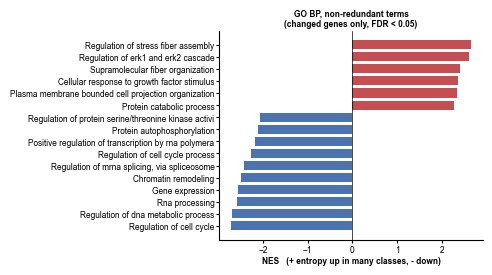

plotted 16 non-redundant terms (6 increasing, 10 decreasing)


In [72]:
# Collapsed, non-redundant GO terms at each end. Red = enriched among genes whose entropy rises
# in many classes; blue = among genes whose entropy falls. Bars are NES; the redundancy filter
# above means neighbouring bars are not near-duplicates of one another.
if not len(pathway_df):
    print('nothing to plot')
else:
    top = pathway_df.sort_values('NES').reset_index(drop=True)
    top['label'] = top['Pathway'].str.slice(0, 52)
    fig, ax = plt.subplots(figsize=(3.4, max(1.6, 0.17 * len(top))))
    ax.barh(range(len(top)), top['NES'].values, height=0.75, linewidth=0,
            color=np.where(top['NES'].values > 0, '#c44e52', '#4c72b0'))
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(top['label'].values)
    ax.axvline(0, color='k', lw=0.5)
    ax.set_xlabel('NES   (+ entropy up in many classes, - down)')
    ax.set_title(f'GO BP, non-redundant terms\n(changed genes only, FDR < {FDR_CUTOFF:g})',
                 pad=PANEL_TITLE_PAD)
    for sp in ('top', 'right'):
        ax.spines[sp].set_visible(False)
    fig.savefig(figpath('06_11_gsea_GOBP_changedgenes.pdf'), bbox_inches='tight', dpi=300)
    plt.show()
    print(f'plotted {len(top)} non-redundant terms '
          f'({int((top.NES > 0).sum())} increasing, {int((top.NES < 0).sum())} decreasing)')